## Notebook 4 – Decision Trees

### 1. EXPLORATORY DATA ANALYSIS (EDA) + FEATURE INSIGHT

In [1]:
# Importing libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import (train_test_split, GridSearchCV)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                            classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.tree import (DecisionTreeClassifier, plot_tree, export_graphviz)
from sklearn.ensemble import RandomForestClassifier

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

np.random.seed(24)
# stores the randomely generated data in seed 24

In [2]:
# Importing dataframe from Notebook 1

df = pd.read_csv('CTR_Prediction_Dataframe.csv').drop('Unnamed: 0', axis = 1)

df.head()

,ad_budget,impressions,click_history,user_engagement_score,time_on_site,device_score,clicked
0,1398.763652,50100.895666,27,0.698608,40.747007,0,0
1,768.989964,50610.176940,28,0.352786,71.475851,1,0
2,905.115892,46363.857264,42,0.535134,71.385886,0,0
3,702.756884,67688.402327,4,0.275047,63.096945,1,0
4,678.755123,22218.359496,45,0.816535,40.374703,1,0


#### Introducing categorical variables like campaign types, seasons, audience segments, and weekdays to allow models to capture time-based trends and consumer behavioral patterns.

In [3]:
# Adding categorical marketing features for Decision Tree modeling

df['campaign_type'] = np.random.choice(['Search', 'Social', 'Display'], size = len(df))

df['seasons'] = np.random.choice(['Spring', 'Summer', 'Autumn', 'Winter'], size = len(df))

df['customer_segment'] = np.random.choice(['New', 'Returning', 'VIP'], size = len(df))

df['weekday'] = np.random.choice(['Weekday', 'Weekend'], size = len(df))

(`pd.get_dummies`) perform a technique called __'One-Hot Encoding'__.

It takes a single text column and breaks it into multiple binary numeric columns containing only 0s and 1s.

Example:

[seasons] column contains Winter, Spring, Summer, and Autumn, gets encoded to: season_Spring, season_Summer, and season_Winter.

(`drop_first = True`) deletes the first created category i.e. season_Autumn to prevents multicollinearity.

In [4]:
df = pd.get_dummies(
    df,
    columns = ['campaign_type', 'seasons', 'customer_segment', 'weekday'],
    drop_first = True
)

In [5]:
df.head()

,ad_budget,impressions,click_history,user_engagement_score,time_on_site,device_score,clicked,campaign_type_Search,campaign_type_Social,seasons_Spring,seasons_Summer,seasons_Winter,customer_segment_Returning,customer_segment_VIP,weekday_Weekend
0,1398.763652,50100.895666,27,0.698608,40.747007,0,0,False,False,False,False,True,False,True,False
1,768.989964,50610.176940,28,0.352786,71.475851,1,0,True,False,False,False,True,True,False,True
2,905.115892,46363.857264,42,0.535134,71.385886,0,0,False,True,False,False,True,True,False,False
3,702.756884,67688.402327,4,0.275047,63.096945,1,0,False,True,False,False,True,False,False,False
4,678.755123,22218.359496,45,0.816535,40.374703,1,0,False,True,False,True,False,True,False,False


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ad_budget                   5000 non-null   float64
 1   impressions                 5000 non-null   float64
 2   click_history               5000 non-null   int64  
 3   user_engagement_score       5000 non-null   float64
 4   time_on_site                5000 non-null   float64
 5   device_score                5000 non-null   int64  
 6   clicked                     5000 non-null   int64  
 7   campaign_type_Search        5000 non-null   bool   
 8   campaign_type_Social        5000 non-null   bool   
 9   seasons_Spring              5000 non-null   bool   
 10  seasons_Summer              5000 non-null   bool   
 11  seasons_Winter              5000 non-null   bool   
 12  customer_segment_Returning  5000 non-null   bool   
 13  customer_segment_VIP        5000 non-null   

In [7]:
# Exporting data for future notebook operations

df.to_csv('CTR_Prediction_Dataframe_modified.csv')

In [8]:
print('Summary Statistics')
df.describe()

Summary Statistics


,ad_budget,impressions,click_history,user_engagement_score,time_on_site,device_score,clicked
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,995.756272,49868.484588,24.660800,0.501541,60.127379,0.688000,0.116800
std,295.239804,14912.159593,14.396847,0.151293,19.971454,0.463356,0.321214
min,-21.458309,-4518.087037,0.000000,-0.046874,-9.760607,0.000000,0.000000
25%,796.705941,39833.664582,12.000000,0.400175,46.563899,0.000000,0.000000
50%,994.610605,49675.658556,25.000000,0.497377,59.810107,1.000000,0.000000
75%,1198.778488,59595.314140,37.000000,0.604109,73.922158,1.000000,0.000000
max,2298.900792,104357.414301,49.000000,1.049246,128.133075,1.000000,1.000000


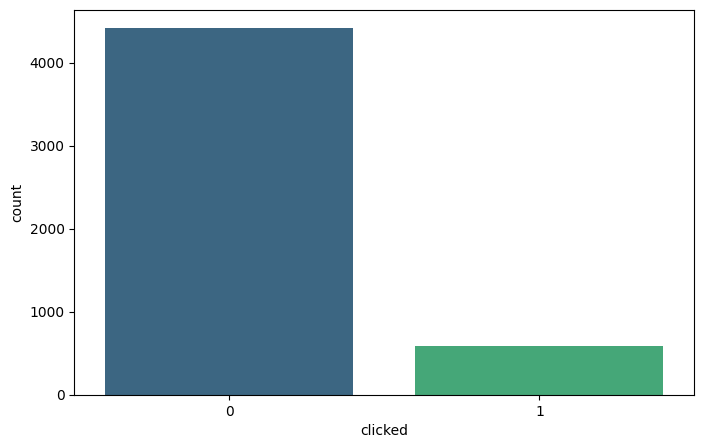

In [9]:
plt.figure(figsize = (8,5))

sns.countplot(x = 'clicked', data = df, palette = 'viridis')

plt.show();

### 2. STRATIFIED SHUFFLE SPLIT

In [10]:
X = df.drop('clicked', axis = 1)

y = df['clicked']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 24,
    stratify = y
)

In [11]:
print(f'The split of X_train {X_train.shape} matches the split of y_train {y_train.shape}; while the split of X_test {X_test.shape} matches the split of y_test {y_test.shape}.')

The split of X_train (4000, 14) matches the split of y_train (4000,); while the split of X_test (1000, 14) matches the split of y_test (1000,).


In [12]:
print('Stratified share of y_train:\n', y_train.value_counts(normalize = True), '\n')
print('Stratified share of y_test:\n', y_test.value_counts(normalize = True))

Stratified share of y_train:
 clicked
0    0.88325
1    0.11675
Name: proportion, dtype: float64 

Stratified share of y_test:
 clicked
0    0.883
1    0.117
Name: proportion, dtype: float64


### 3. DECISION TREE

A **Decision Tree** is a machine learning algorithm that predicts outcomes by splitting data into branches based on "yes or no" questions.

__Baseline Tree (Gini)__: 

By default, scikit-learn uses _Gini Impurity_ the mathematical engine the tree uses to split the marketing data. Gini focuses on minimising misclassification risk. It asks: 'If I split the data here, how likely am I to randomly label a campaign incorrectly?'. It computes incredibly fast.

Core Concepts:

__Root Node__: The very top of the tree containing the first question, e.g., Is the campaign_type Search?.

__Decision Nodes__: Internal branches where data splits further based on new conditions.

__Leaf Nodes__: The final endpoints where the tree stops splitting and makes its final prediction, e.g., campaign_type is Display.

In [13]:
tree_cl = DecisionTreeClassifier(random_state = 24)

tree_cl.fit(X_train, y_train)

treecl_pred = tree_cl.predict(X_test)

print('DecisionTree Gini Accuracy Score:', accuracy_score(y_test, treecl_pred))
print('DecisionTree Gini Precision Score:', np.round(precision_score(y_test, treecl_pred), 3))
print('DecisionTree Gini Recall Score:', np.round(recall_score(y_test, treecl_pred), 3))
print('DecisionTree Gini F1 Score:', f1_score(y_test, treecl_pred))

DecisionTree Gini Accuracy Score: 0.934
DecisionTree Gini Precision Score: 0.707
DecisionTree Gini Recall Score: 0.744
DecisionTree Gini F1 Score: 0.725


In [14]:
print('DecisionTree Gini Classification Summary:\n', classification_report(y_test, treecl_pred))

DecisionTree Gini Classification Summary:
               precision    recall  f1-score   support

           0       0.97      0.96      0.96       883
           1       0.71      0.74      0.72       117

    accuracy                           0.93      1000
   macro avg       0.84      0.85      0.84      1000
weighted avg       0.94      0.93      0.93      1000



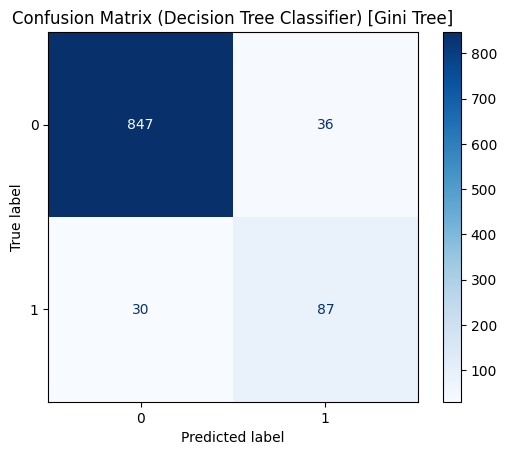

In [15]:
# Plotting Tree Matrix

ConfusionMatrixDisplay(confusion_matrix(y_test, treecl_pred)).plot(cmap = 'Blues');
plt.title('Confusion Matrix (Decision Tree Classifier) [Gini Tree]');

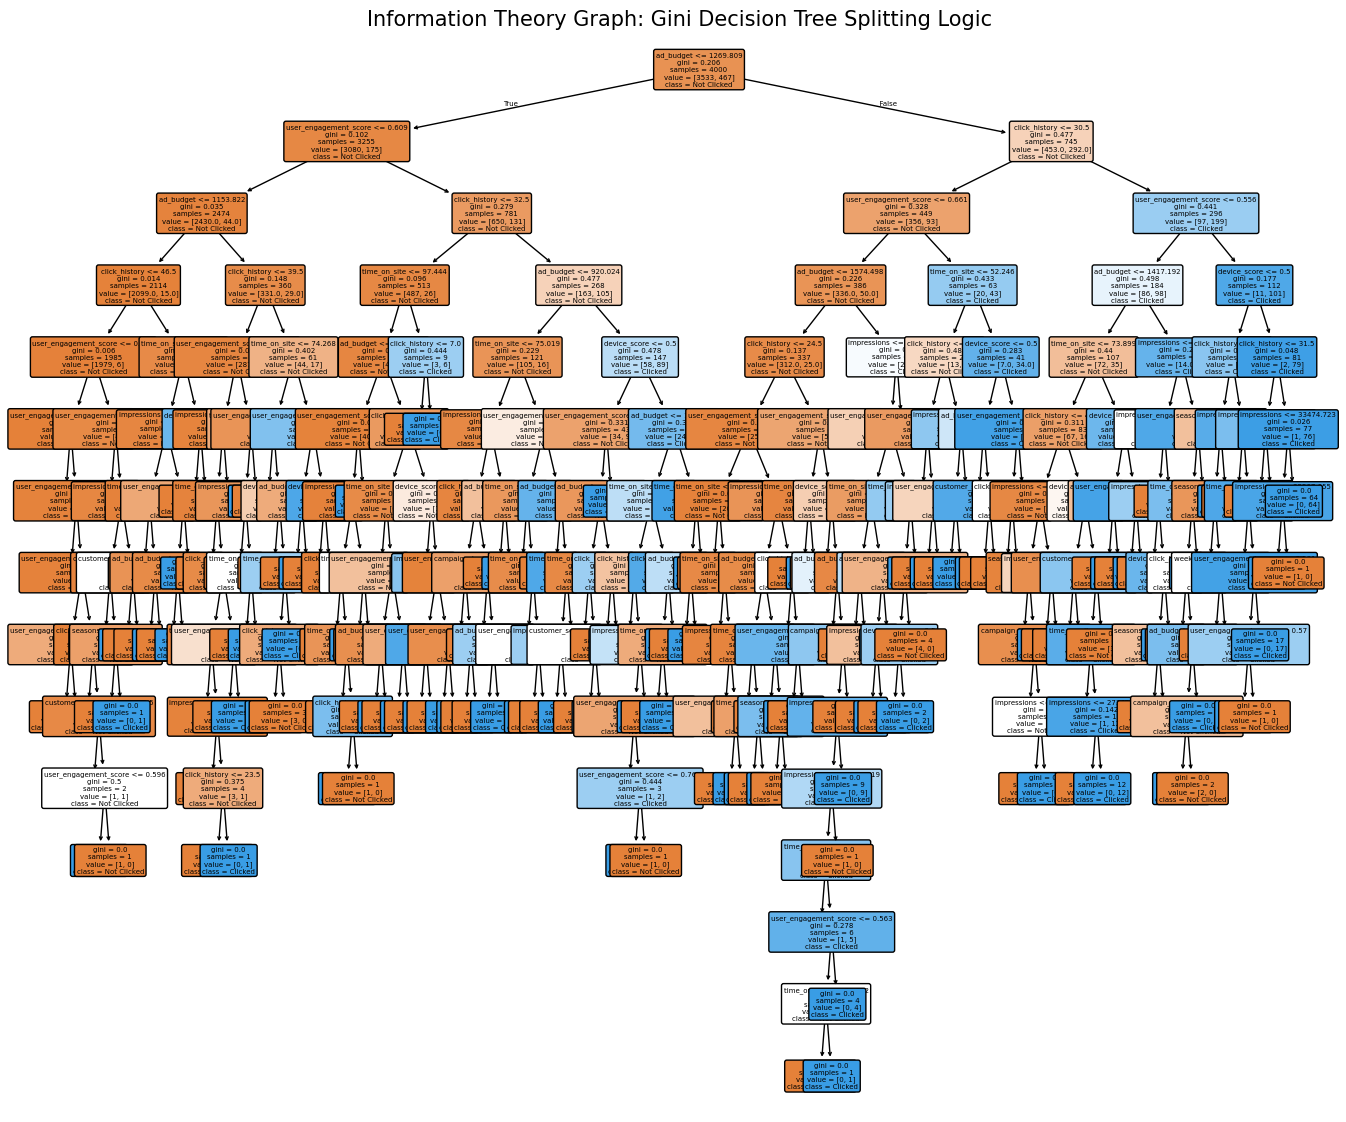

In [16]:
# Plotting (baseline) Gini Decision Tree

plt.figure(figsize = (16,14))

plot_tree(
    tree_cl,
    feature_names = X.columns,
    class_names = ['Not Clicked', 'Clicked'], # maps the model's binary outputs (0 and 1) to labels
    filled = True,                            # color-codes the nodes based on their majority class and purity
    rounded = True,                           # changes the node boxes from sharp rectangles to rounded rectangles
    fontsize = 5
)

plt.title('Information Theory Graph: Gini Decision Tree Splitting Logic', fontsize = 15)
plt.show();

### 4. ENTROPY TREE

__Improved Tree (Entropy)__: 

_Entropy_ comes from physics and information theory. It measures the raw chaos or randomness in a dataset. It asks: 'How much new information do I gain by making this specific cut?'. It uses logarithmic math to calculate Information Gain, resulting in highly structured, exploratory paths.

In [17]:
tree_entropy = DecisionTreeClassifier(
    criterion = 'entropy',
    random_state = 24
)

tree_entropy.fit(X_train, y_train)

treentropy_pred = tree_entropy.predict(X_test)

print('DecisionTree Entropy Accuracy Score:', accuracy_score(y_test, treentropy_pred))
print('DecisionTree Entropy Precision Score:', np.round(precision_score(y_test, treentropy_pred), 3))
print('DecisionTree Entropy Recall Score:', np.round(recall_score(y_test, treentropy_pred), 3))
print('DecisionTree Entropy F1 Score:', np.round(f1_score(y_test, treentropy_pred), 3))

DecisionTree Entropy Accuracy Score: 0.943
DecisionTree Entropy Precision Score: 0.763
DecisionTree Entropy Recall Score: 0.744
DecisionTree Entropy F1 Score: 0.753


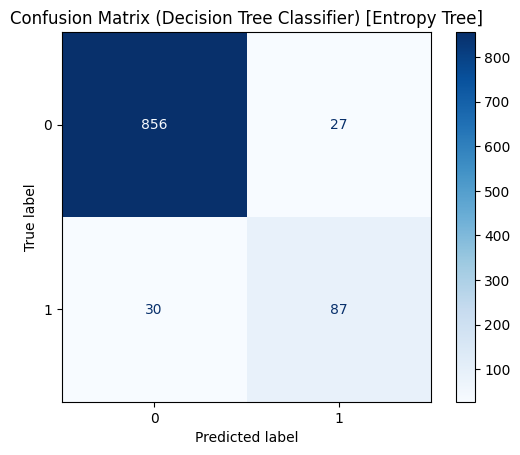

In [18]:
# Plotting Entropy Tree Matrix

ConfusionMatrixDisplay(confusion_matrix(y_test, treentropy_pred)).plot(cmap = 'Blues');
plt.title('Confusion Matrix (Decision Tree Classifier) [Entropy Tree]');

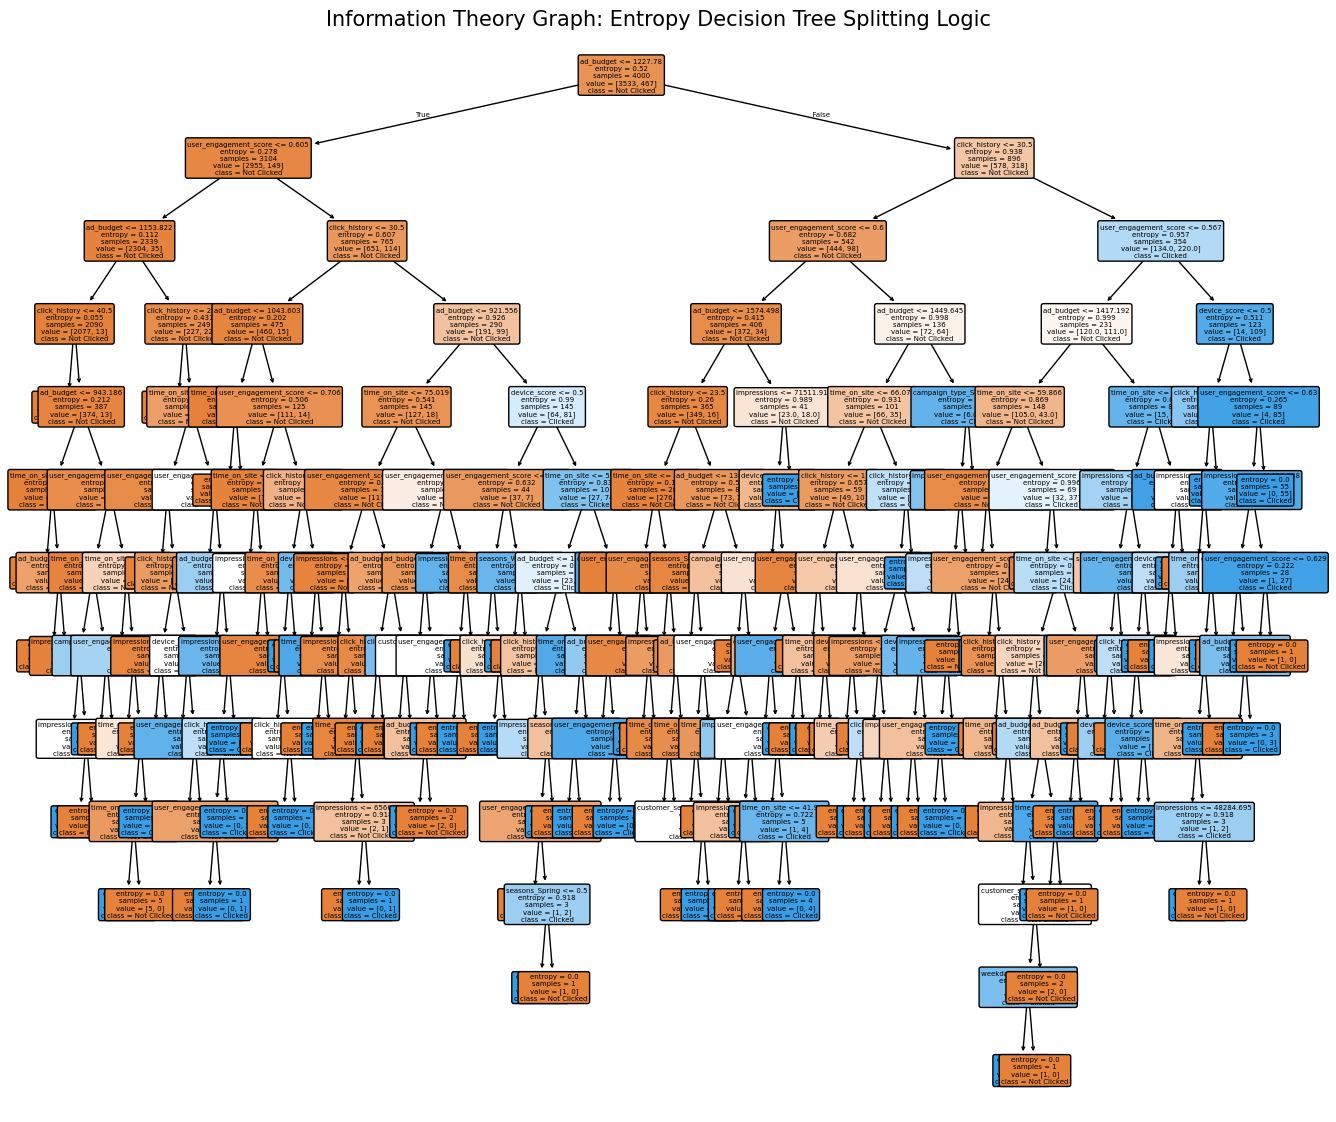

In [19]:
# plotting Entropy Decision tree

plt.figure(figsize = (16,14))

plot_tree(
    tree_entropy,
    feature_names = X.columns,
    class_names = ['Not Clicked', 'Clicked'],
    filled = True,
    rounded = True,
    fontsize = 5
)

plt.title('Information Theory Graph: Entropy Decision Tree Splitting Logic', fontsize = 15)
plt.show();

#### Key takeaways

Both tree splitting (Gini and Entropy) shows _ad_budget_ at the very top of your flowchart. Information theory mathematically proves that total ad budget allocation is the absolute single most powerful point of chaos — meaning it is the primary variable that dictates whether campaigns succeed or fail.

Comparing both raw confusion matrices (Gini and Entropy):

__Entropy tree__ is the better Matrix choice compared to default Gini tree.

While both trees caught the exact same number of successful campaigns (87 True Positives), the Entropy tree eliminated 9 False Positive mistakes. By choosing Information Gain, Entropy model built more logical boundaries around new dummy variables, raising the Precision Score to 0.763 and F1-Score to 0.753.

### 5. MAXIMUM DEPTH EXPERIMENT

The Maximum Depth experiment presents a visual map of the Bias-Variance Trade-off and reveals the exact moment Decision Tree stops learning real patterns and starts overfitting to marketing data.

In [20]:
depth_results = []

depths = range(1,16)

# initialising the tree with the current max_depth restriction
for depth in depths:
    tree_depth_model = DecisionTreeClassifier(
        max_depth = depth,
        criterion = 'entropy',      
        # inserting the 'entropy' engine to split the marketing data
        random_state = 24
    )

    tree_depth_model.fit(X_train, y_train)

    tree_depth_train = tree_depth_model.predict(X_train)
    tree_depth_pred = tree_depth_model.predict(X_test)

    depth_results.append({
        'Max_Depth': depth,
        'Train_Accuracy': accuracy_score(y_train, tree_depth_train),
        'Test_Accuracy': accuracy_score(y_test, tree_depth_pred)
    })

df_depth = pd.DataFrame(depth_results)

df_depth.sort_values(by = ['Test_Accuracy', 'Train_Accuracy'], ascending = False).head(5)

,Max_Depth,Train_Accuracy,Test_Accuracy
8,9,0.99625,0.946
11,12,1.00000,0.943
12,13,1.00000,0.943
13,14,1.00000,0.943
14,15,1.00000,0.943


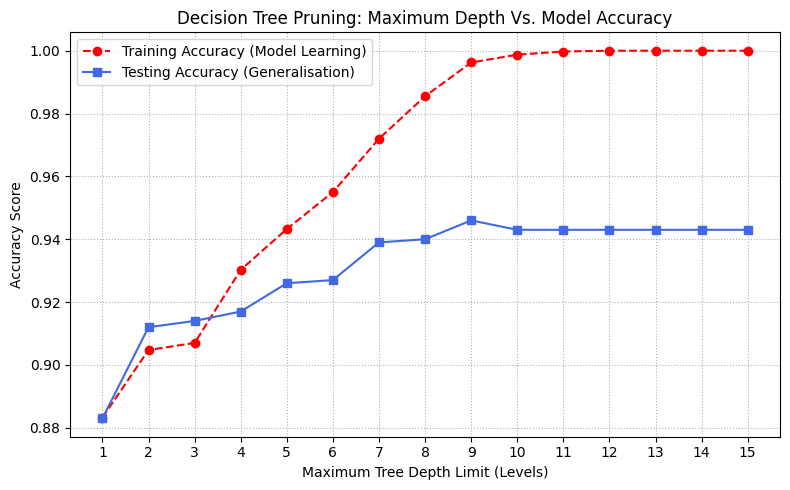

In [21]:
# Plotting the Validation Curve

plt.figure(figsize = (8,5))

plt.plot(df_depth['Max_Depth'], df_depth['Train_Accuracy'], marker = 'o', color = 'red', linestyle = '--',
         label = 'Training Accuracy (Model Learning)'
)
plt.plot(df_depth['Max_Depth'], df_depth['Test_Accuracy'], marker = 's', color = 'royalblue', linestyle = '-',
         label = 'Testing Accuracy (Generalisation)'
)

plt.title('Decision Tree Pruning: Maximum Depth Vs. Model Accuracy')
plt.xlabel('Maximum Tree Depth Limit (Levels)')
plt.ylabel('Accuracy Score')
plt.xticks(depths)

plt.legend()
plt.grid(linestyle = ':')
plt.tight_layout()
plt.show();

#### Key takeaway

Above plot shows that at Max_Depth = 9, tree hits its absolute testing peak at 94.6% accuracy (df_depth). However, training accuracy score for that same row is sitting at 99.6%. This means a single constraint (max_depth) is not enough to stop the model from over-customising its rules. By the time the tree reaches depth level 12, it has achieved 100% training accuracy, completely memorising the dataset, which causes test scores to fall.

### 6. PRE-PRUNING

The purpose of __pre-pruning__ is to stop the tree from growing before it has a chance to create overly specific, hyper-localised rules that lead to overfitting. Instead of letting the tree run wild and then trimming it backward, pre-pruning forces the algorithm to follow strict structural boundary restrictions while it is actively building its nodes.

In [22]:
# Initialising your pre-pruned structural configuration

tree_pruned_model = DecisionTreeClassifier(
    max_depth = 5,
    # acts as a hard stop at depth 5
    min_samples_leaf = 10,
    # every final 'leaf' (prediction bucket) must contain at least 10 campaigns
    min_samples_split = 20,
    # a node is no longer allowed to split unless it contains at least 20 campaign records
    criterion = 'entropy',
    random_state = 24
)

tree_pruned_model.fit(X_train, y_train)

tree_pruned_pred = tree_pruned_model.predict(X_test)

print('DecisionTree Entropy Pruned Accuracy Score:', accuracy_score(y_test, tree_pruned_pred))
print('DecisionTree Entropy Pruned Precision Score:', np.round(precision_score(y_test, tree_pruned_pred), 3))
print('DecisionTree Entropy Pruned Recall Score:', np.round(recall_score(y_test, tree_pruned_pred), 3))
print('DecisionTree Entropy Pruned F1 Score:', np.round(f1_score(y_test, tree_pruned_pred), 3))

DecisionTree Entropy Pruned Accuracy Score: 0.929
DecisionTree Entropy Pruned Precision Score: 0.735
DecisionTree Entropy Pruned Recall Score: 0.615
DecisionTree Entropy Pruned F1 Score: 0.67


#### Key takeaway

Pre-Pruned F1-Score dropped to 0.6700 (down from your unconstrained Entropy score of 0.7530). Recall also dropped to 0.6150, meaning that by capping the tree at max_depth = 5 and adding strict sample limits, the tree growth was cut off too early. The model became too simplistic (underfitting) and missed a large portion of the successful marketing campaigns.

Pre-pruning failed to find a healthy middle ground potentially due to guessing parameters like min_samples_leaf = 10 is arbitrary patchwork.

### 7. COST COMPLEXITY PRUNING (POST-PRUNING)

Cost Complexity Pruning (Post-Pruning) uses an advanced optimisation parameter called (`alpha`) to systematically prune the tree backward.

Mathematically, it assigns an (alpha) score to every node based on its cost-efficiency:

_Cost = Impurity of Leaves + alpha * Number of Leaves_

A tiny (alpha) keeps complex branches alive. A large (alpha) aggressively lops off massive sections of the tree.

In [23]:
# Building an unconstrained tree to extract the true mathematical pruning path

base_tree = DecisionTreeClassifier(criterion = 'entropy', random_state = 24)
# tells the tree how to measure the "purity" of a split

path = base_tree.cost_complexity_pruning_path(X_train, y_train)
# builds a massive, completely unpruned tree using training data

ccp_alphas = path.ccp_alphas
# array of all unique alpha inflection points

ccp_results = []

# Iterating through each alpha to find the optimal post-pruning threshold
# the last alpha is excluded because it trims the entire tree into a single leaf node

for alpha in ccp_alphas[:-1]:
    tree_postpruned_model = DecisionTreeClassifier(
        criterion = 'entropy',
        ccp_alpha = alpha,
        random_state = 24
    )
    tree_postpruned_model.fit(X_train, y_train)
    
    tree_postpruned_train = tree_postpruned_model.predict(X_train)
    tree_postpruned_pred = tree_postpruned_model.predict(X_test)

    ccp_results.append({
        'Alpha': alpha,
        'Train_F1': f1_score(y_train, tree_postpruned_train),
        'Test_F1': f1_score(y_test, tree_postpruned_pred)
    })

df_ccp = pd.DataFrame(ccp_results)

df_ccp.sort_values(by = ['Test_F1', 'Train_F1'], ascending = False).head(5)

,Alpha,Train_F1,Test_F1
76,0.001644,0.870130,0.767241
65,0.001462,0.895361,0.763948
74,0.001621,0.871905,0.763948
75,0.001622,0.871905,0.763948
66,0.001494,0.891775,0.758621


In [24]:
df_ccp['Alpha'][76]

np.float64(0.0016435647295031258)

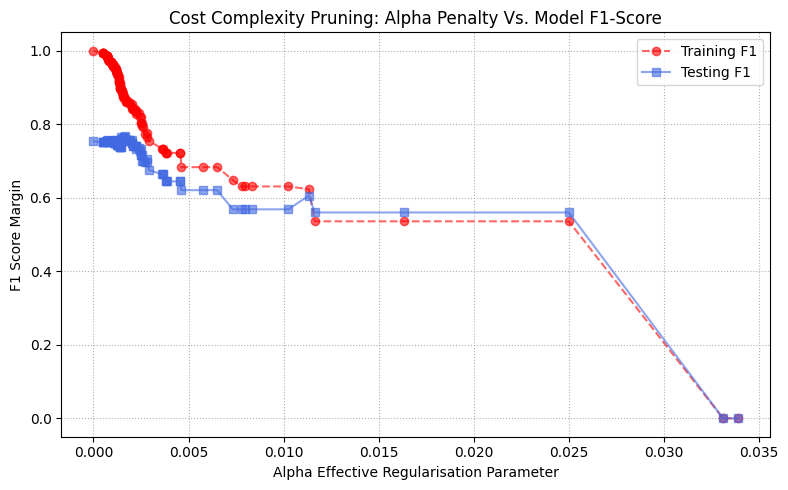

In [25]:
# Plot the Post-Pruning Validation Curve

plt.figure(figsize = (8,5))

plt.plot(df_ccp['Alpha'], df_ccp['Train_F1'], color = 'red', marker = 'o', linestyle = '--', alpha = 0.6,
         label = 'Training F1'
)

plt.plot(df_ccp['Alpha'], df_ccp['Test_F1'], color = 'royalblue', marker = 's', linestyle = '-', alpha = 0.6,
         label = 'Testing F1'
)

plt.title('Cost Complexity Pruning: Alpha Penalty Vs. Model F1-Score')
plt.xlabel('Alpha Effective Regularisation Parameter')
plt.ylabel('F1 Score Margin')

plt.legend()
plt.grid(linestyle = ':')
plt.tight_layout()
plt.show();

#### Key takeaway

By applying Cost Complexity Pruning, the model was successfully saved from the underfitting trap of pre-pruning:

Unconstrained Tree: F1 = 0.7532 (Overfitting)

Pre-Pruned Tree: F1 = 0.6700 (Underfitting)

__Post-Pruned Tree (Alpha = 0.001644): F1 = 0.7672 (The Optimal parameter)__

### 8. BASELINE RANDOM FOREST CLASSIFIER

In [26]:
# Initialising the Random Forest ensemble configuration

rf_base_model = RandomForestClassifier(
    n_estimators = 100,
    # creates 100 voting trees
    criterion = 'entropy',
    # applying the winning splitting metric
    ccp_alpha = df_ccp['Alpha'][76],
    # applying optimal post-pruning alpha index[76]
    random_state = 24,
    n_jobs = -1
    # uses all CPU cores for high-speed processing
)

rf_base_model.fit(X_train, y_train)

rf_base_pred = rf_base_model.predict(X_test)

print('Random Forest Classification Report:\n', classification_report(y_test, rf_base_pred))

Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       883
           1       1.00      0.58      0.74       117

    accuracy                           0.95      1000
   macro avg       0.97      0.79      0.85      1000
weighted avg       0.95      0.95      0.95      1000



#### Key takeaway

Random Forest achieved a flawless Precision Score of 1.00 (100%) for (Class 1: Clicked). It means that out of all the campaigns the forest predicted would succeed, every single one actually did. Zero wasted ad spend on false leads. 

However, Recall Score dropped to 0.58 (58%), dragging F1-Score to 0.74. By forcing every tree in the forest to use the harsh ccp_alpha approx. 0.001644 constraint calculated for single tree, the ensemble got over-pruned. The forest became overly cautious, missing 42% of your true revenue opportunities.

### 9. GRID SEARCH CV (HYPERPARAMETER TUNING)

__Grid Search__ acts like a combination lock cracker for machine learning. Instead of manually guessing the best settings (hyperparameters) for Random Forest, Grid Search systematically builds a model for every possible combination of settings to find the absolute winner.

In [27]:
# Defining the parameter matrix specifically tailored for an ensemble

param_grid = {
    'n_estimators': [50, 100, 200],
    # number of voting trees
    'max_features': ['sqrt', 'log2'],
    # random columns allowed per split
    'ccp_alpha': [0.0, 0.0005, 0.001]
    # testing lighter pruning values
}

# Initialising the Grid Search engine with 5-fold cross-validation

rf_grid = GridSearchCV(
    estimator = RandomForestClassifier(criterion = 'entropy', random_state = 24),
    param_grid = param_grid,
    cv = 5,
    scoring = 'f1',
    # prioritising 'f1' as the scoring metric to balance precision and recall
    n_jobs = -1
)

rf_grid.fit(X_train, y_train)

print('Optimal Parameters Discovered:', rf_grid.best_params_, '\n')
print('Optimal Validation F1-Score:', rf_grid.best_score_)

Optimal Parameters Discovered: {'ccp_alpha': 0.0005, 'max_features': 'sqrt', 'n_estimators': 200} 

Optimal Validation F1-Score: 0.7334005343794676


#### Key takeaway

Grid Search CV successfully optimized ensemble. The model rejected the high alpha penalty from single tree and selected a much lighter ccp_alpha = 0.0005, confirming that the forest requires more structural depth to function properly. It also locked in n_estimators =  200, proving that a larger pool of voting trees successfully maximises performance on your expanded dataset.

### 10. EXPORT GRAPHVIZ (VISUALISATION)

In [28]:
# Extracting the optimal trained estimator from Grid Search

rf_optimal_model = rf_grid.best_estimator_

rf_optimal_pred = rf_optimal_model.predict(X_test)

print('Optimal Grid Search Classification Report:\n', classification_report(y_test, rf_optimal_pred))

Optimal Grid Search Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98       883
           1       1.00      0.62      0.77       117

    accuracy                           0.96      1000
   macro avg       0.98      0.81      0.87      1000
weighted avg       0.96      0.96      0.95      1000



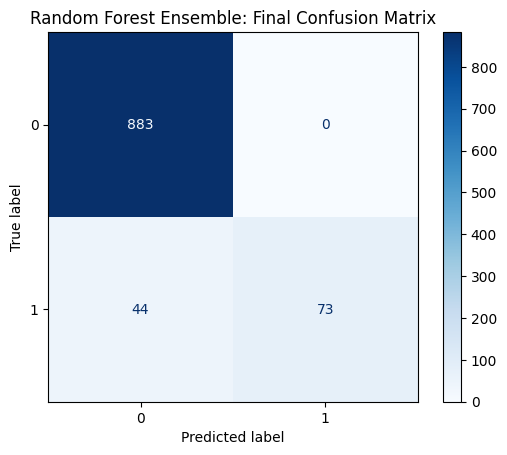

In [29]:
# Plotting final confusion matrix

ConfusionMatrixDisplay(confusion_matrix(y_test, rf_optimal_pred)).plot(cmap = 'Blues')

plt.title('Random Forest Ensemble: Final Confusion Matrix');

### GraphVIZ

In [34]:
# EXPORT GRAPHVIZ: Isolates and extracts a single tree from the forest

isolated_tree = rf_optimal_model.estimators_[0]
#  index [0] sliced to extract the first individual estimator flowchart

export_graphviz(
    isolated_tree,
    out_file = 'marketing_forest_tree.dot',
    # saves a .dot text file in notebook directory
    feature_names = list(X.columns),
    class_names = ['Not Clicked', 'Clicked'],
    filled = True,
    rounded = True,
    special_characters = True
)

The Isolated Tree is Visible on [My Graphviz Diagram][link] inside this notebook.

[link]: https://dreampuf.github.io/GraphvizOnline/?engine=dot#digraph%20Tree%20%7B%0D%0Anode%20%5Bshape%3Dbox%2C%20style%3D%22filled%2C%20rounded%22%2C%20color%3D%22black%22%2C%20fontname%3D%22helvetica%22%5D%20%3B%0D%0Aedge%20%5Bfontname%3D%22helvetica%22%5D%20%3B%0D%0A0%20%5Blabel%3D%3Cclick_history%20%26le%3B%2031.5%3Cbr%2F%3Eentropy%20%3D%200.507%3Cbr%2F%3Esamples%20%3D%202534%3Cbr%2F%3Evalue%20%3D%20%5B3551%2C%20449%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e89152%22%5D%20%3B%0D%0A1%20%5Blabel%3D%3Cseasons_Summer%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.273%3Cbr%2F%3Esamples%20%3D%201628%3Cbr%2F%3Evalue%20%3D%20%5B2464%2C%20121%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e68743%22%5D%20%3B%0D%0A0%20-%3E%201%20%5Blabeldistance%3D2.5%2C%20labelangle%3D45%2C%20headlabel%3D%22True%22%5D%20%3B%0D%0A2%20%5Blabel%3D%3Cdevice_score%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.286%3Cbr%2F%3Esamples%20%3D%201250%3Cbr%2F%3Evalue%20%3D%20%5B1889%2C%2099%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e68843%22%5D%20%3B%0D%0A1%20-%3E%202%20%3B%0D%0A3%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2082.097%3Cbr%2F%3Eentropy%20%3D%200.115%3Cbr%2F%3Esamples%20%3D%20377%3Cbr%2F%3Evalue%20%3D%20%5B574%2C%209%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e5833c%22%5D%20%3B%0D%0A2%20-%3E%203%20%3B%0D%0A4%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2033.487%3Cbr%2F%3Eentropy%20%3D%200.037%3Cbr%2F%3Esamples%20%3D%20324%3Cbr%2F%3Evalue%20%3D%20%5B500%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e5823a%22%5D%20%3B%0D%0A3%20-%3E%204%20%3B%0D%0A5%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.718%3Cbr%2F%3Eentropy%20%3D%200.146%3Cbr%2F%3Esamples%20%3D%2032%3Cbr%2F%3Evalue%20%3D%20%5B47%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e6843d%22%5D%20%3B%0D%0A4%20-%3E%205%20%3B%0D%0A6%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2031%3Cbr%2F%3Evalue%20%3D%20%5B47%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A5%20-%3E%206%20%3B%0D%0A7%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A5%20-%3E%207%20%3B%0D%0A8%20%5Blabel%3D%3Cseasons_Winter%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.023%3Cbr%2F%3Esamples%20%3D%20292%3Cbr%2F%3Evalue%20%3D%20%5B453%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A4%20-%3E%208%20%3B%0D%0A9%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%20207%3Cbr%2F%3Evalue%20%3D%20%5B321%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A8%20-%3E%209%20%3B%0D%0A10%20%5Blabel%3D%3Ccustomer_segment_Returning%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.064%3Cbr%2F%3Esamples%20%3D%2085%3Cbr%2F%3Evalue%20%3D%20%5B132%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e5823b%22%5D%20%3B%0D%0A8%20-%3E%2010%20%3B%0D%0A11%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2055%3Cbr%2F%3Evalue%20%3D%20%5B89%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A10%20-%3E%2011%20%3B%0D%0A12%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2067.609%3Cbr%2F%3Eentropy%20%3D%200.156%3Cbr%2F%3Esamples%20%3D%2030%3Cbr%2F%3Evalue%20%3D%20%5B43%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e6843e%22%5D%20%3B%0D%0A10%20-%3E%2012%20%3B%0D%0A13%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2021%3Cbr%2F%3Evalue%20%3D%20%5B31%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A12%20-%3E%2013%20%3B%0D%0A14%20%5Blabel%3D%3Cclick_history%20%26le%3B%2028.5%3Cbr%2F%3Eentropy%20%3D%200.391%3Cbr%2F%3Esamples%20%3D%209%3Cbr%2F%3Evalue%20%3D%20%5B12%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e78c49%22%5D%20%3B%0D%0A12%20-%3E%2014%20%3B%0D%0A15%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%208%3Cbr%2F%3Evalue%20%3D%20%5B12%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A14%20-%3E%2015%20%3B%0D%0A16%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A14%20-%3E%2016%20%3B%0D%0A17%20%5Blabel%3D%3Cimpressions%20%26le%3B%2047315.979%3Cbr%2F%3Eentropy%20%3D%200.424%3Cbr%2F%3Esamples%20%3D%2053%3Cbr%2F%3Evalue%20%3D%20%5B74%2C%207%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e78d4c%22%5D%20%3B%0D%0A3%20-%3E%2017%20%3B%0D%0A18%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2022%3Cbr%2F%3Evalue%20%3D%20%5B35%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A17%20-%3E%2018%20%3B%0D%0A19%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.62%3Cbr%2F%3Eentropy%20%3D%200.615%3Cbr%2F%3Esamples%20%3D%2031%3Cbr%2F%3Evalue%20%3D%20%5B39%2C%207%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ea985d%22%5D%20%3B%0D%0A17%20-%3E%2019%20%3B%0D%0A20%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2024%3Cbr%2F%3Evalue%20%3D%20%5B33%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A19%20-%3E%2020%20%3B%0D%0A21%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2090.77%3Cbr%2F%3Eentropy%20%3D%200.996%3Cbr%2F%3Esamples%20%3D%207%3Cbr%2F%3Evalue%20%3D%20%5B6%2C%207%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23e3f1fb%22%5D%20%3B%0D%0A19%20-%3E%2021%20%3B%0D%0A22%20%5Blabel%3D%3Ccampaign_type_Search%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.918%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B6%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f2c09c%22%5D%20%3B%0D%0A21%20-%3E%2022%20%3B%0D%0A23%20%5Blabel%3D%3Ccampaign_type_Social%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.971%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23bddef6%22%5D%20%3B%0D%0A22%20-%3E%2023%20%3B%0D%0A24%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A23%20-%3E%2024%20%3B%0D%0A25%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A23%20-%3E%2025%20%3B%0D%0A26%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A22%20-%3E%2026%20%3B%0D%0A27%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A21%20-%3E%2027%20%3B%0D%0A28%20%5Blabel%3D%3Cimpressions%20%26le%3B%2070395.836%3Cbr%2F%3Eentropy%20%3D%200.343%3Cbr%2F%3Esamples%20%3D%20873%3Cbr%2F%3Evalue%20%3D%20%5B1315%2C%2090%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e78a47%22%5D%20%3B%0D%0A2%20-%3E%2028%20%3B%0D%0A29%20%5Blabel%3D%3Cclick_history%20%26le%3B%2017.5%3Cbr%2F%3Eentropy%20%3D%200.313%3Cbr%2F%3Esamples%20%3D%20802%3Cbr%2F%3Evalue%20%3D%20%5B1220%2C%2073%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e78945%22%5D%20%3B%0D%0A28%20-%3E%2029%20%3B%0D%0A30%20%5Blabel%3D%3Ccampaign_type_Search%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.182%3Cbr%2F%3Esamples%20%3D%20457%3Cbr%2F%3Evalue%20%3D%20%5B708%2C%2020%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e6853f%22%5D%20%3B%0D%0A29%20-%3E%2030%20%3B%0D%0A31%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.856%3Cbr%2F%3Eentropy%20%3D%200.16%3Cbr%2F%3Esamples%20%3D%20294%3Cbr%2F%3Evalue%20%3D%20%5B460%2C%2011%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e6843e%22%5D%20%3B%0D%0A30%20-%3E%2031%20%3B%0D%0A32%20%5Blabel%3D%3Cclick_history%20%26le%3B%2010.5%3Cbr%2F%3Eentropy%20%3D%200.086%3Cbr%2F%3Esamples%20%3D%20289%3Cbr%2F%3Evalue%20%3D%20%5B459%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e5823b%22%5D%20%3B%0D%0A31%20-%3E%2032%20%3B%0D%0A33%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%20179%3Cbr%2F%3Evalue%20%3D%20%5B295%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A32%20-%3E%2033%20%3B%0D%0A34%20%5Blabel%3D%3Cad_budget%20%26le%3B%201365.268%3Cbr%2F%3Eentropy%20%3D%200.192%3Cbr%2F%3Esamples%20%3D%20110%3Cbr%2F%3Evalue%20%3D%20%5B164%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e6853f%22%5D%20%3B%0D%0A32%20-%3E%2034%20%3B%0D%0A35%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2097%3Cbr%2F%3Evalue%20%3D%20%5B153%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A34%20-%3E%2035%20%3B%0D%0A36%20%5Blabel%3D%3Cimpressions%20%26le%3B%2065217.223%3Cbr%2F%3Eentropy%20%3D%200.896%3Cbr%2F%3Esamples%20%3D%2013%3Cbr%2F%3Evalue%20%3D%20%5B11%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f1ba93%22%5D%20%3B%0D%0A34%20-%3E%2036%20%3B%0D%0A37%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2074.783%3Cbr%2F%3Eentropy%20%3D%200.75%3Cbr%2F%3Esamples%20%3D%2012%3Cbr%2F%3Evalue%20%3D%20%5B11%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eca36f%22%5D%20%3B%0D%0A36%20-%3E%2037%20%3B%0D%0A38%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2045.17%3Cbr%2F%3Eentropy%20%3D%200.414%3Cbr%2F%3Esamples%20%3D%2010%3Cbr%2F%3Evalue%20%3D%20%5B11%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e78c4b%22%5D%20%3B%0D%0A37%20-%3E%2038%20%3B%0D%0A39%20%5Blabel%3D%3Ccampaign_type_Social%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.918%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f2c09c%22%5D%20%3B%0D%0A38%20-%3E%2039%20%3B%0D%0A40%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A39%20-%3E%2040%20%3B%0D%0A41%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A39%20-%3E%2041%20%3B%0D%0A42%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%207%3Cbr%2F%3Evalue%20%3D%20%5B9%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A38%20-%3E%2042%20%3B%0D%0A43%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A37%20-%3E%2043%20%3B%0D%0A44%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A36%20-%3E%2044%20%3B%0D%0A45%20%5Blabel%3D%3Cclick_history%20%26le%3B%2014.0%3Cbr%2F%3Eentropy%20%3D%200.592%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%206%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%235aade9%22%5D%20%3B%0D%0A31%20-%3E%2045%20%3B%0D%0A46%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%206%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A45%20-%3E%2046%20%3B%0D%0A47%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A45%20-%3E%2047%20%3B%0D%0A48%20%5Blabel%3D%3Ccustomer_segment_VIP%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.219%3Cbr%2F%3Esamples%20%3D%20163%3Cbr%2F%3Evalue%20%3D%20%5B248%2C%209%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e68640%22%5D%20%3B%0D%0A30%20-%3E%2048%20%3B%0D%0A49%20%5Blabel%3D%3Cseasons_Winter%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.189%3Cbr%2F%3Esamples%20%3D%20111%3Cbr%2F%3Evalue%20%3D%20%5B168%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e6853f%22%5D%20%3B%0D%0A48%20-%3E%2049%20%3B%0D%0A50%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2081.352%3Cbr%2F%3Eentropy%20%3D%200.118%3Cbr%2F%3Esamples%20%3D%2079%3Cbr%2F%3Evalue%20%3D%20%5B123%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e5833c%22%5D%20%3B%0D%0A49%20-%3E%2050%20%3B%0D%0A51%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2066%3Cbr%2F%3Evalue%20%3D%20%5B103%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A50%20-%3E%2051%20%3B%0D%0A52%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.674%3Cbr%2F%3Eentropy%20%3D%200.439%3Cbr%2F%3Esamples%20%3D%2013%3Cbr%2F%3Evalue%20%3D%20%5B20%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e88e4d%22%5D%20%3B%0D%0A50%20-%3E%2052%20%3B%0D%0A53%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2010%3Cbr%2F%3Evalue%20%3D%20%5B18%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A52%20-%3E%2053%20%3B%0D%0A54%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2084.812%3Cbr%2F%3Eentropy%20%3D%201.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ffffff%22%5D%20%3B%0D%0A52%20-%3E%2054%20%3B%0D%0A55%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A54%20-%3E%2055%20%3B%0D%0A56%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A54%20-%3E%2056%20%3B%0D%0A57%20%5Blabel%3D%3Cad_budget%20%26le%3B%201502.31%3Cbr%2F%3Eentropy%20%3D%200.337%3Cbr%2F%3Esamples%20%3D%2032%3Cbr%2F%3Evalue%20%3D%20%5B45%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e78946%22%5D%20%3B%0D%0A49%20-%3E%2057%20%3B%0D%0A58%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2030%3Cbr%2F%3Evalue%20%3D%20%5B45%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A57%20-%3E%2058%20%3B%0D%0A59%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A57%20-%3E%2059%20%3B%0D%0A60%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.751%3Cbr%2F%3Eentropy%20%3D%200.276%3Cbr%2F%3Esamples%20%3D%2052%3Cbr%2F%3Evalue%20%3D%20%5B80%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e68743%22%5D%20%3B%0D%0A48%20-%3E%2060%20%3B%0D%0A61%20%5Blabel%3D%3Cclick_history%20%26le%3B%204.5%3Cbr%2F%3Eentropy%20%3D%200.096%3Cbr%2F%3Esamples%20%3D%2051%3Cbr%2F%3Evalue%20%3D%20%5B80%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e5833b%22%5D%20%3B%0D%0A60%20-%3E%2061%20%3B%0D%0A62%20%5Blabel%3D%3Cseasons_Spring%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.391%3Cbr%2F%3Esamples%20%3D%208%3Cbr%2F%3Evalue%20%3D%20%5B12%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e78c49%22%5D%20%3B%0D%0A61%20-%3E%2062%20%3B%0D%0A63%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B11%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A62%20-%3E%2063%20%3B%0D%0A64%20%5Blabel%3D%3Centropy%20%3D%201.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ffffff%22%5D%20%3B%0D%0A62%20-%3E%2064%20%3B%0D%0A65%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2043%3Cbr%2F%3Evalue%20%3D%20%5B68%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A61%20-%3E%2065%20%3B%0D%0A66%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A60%20-%3E%2066%20%3B%0D%0A67%20%5Blabel%3D%3Cad_budget%20%26le%3B%201053.396%3Cbr%2F%3Eentropy%20%3D%200.449%3Cbr%2F%3Esamples%20%3D%20345%3Cbr%2F%3Evalue%20%3D%20%5B512%2C%2053%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e88e4d%22%5D%20%3B%0D%0A29%20-%3E%2067%20%3B%0D%0A68%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%20194%3Cbr%2F%3Evalue%20%3D%20%5B332%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A67%20-%3E%2068%20%3B%0D%0A69%20%5Blabel%3D%3Cad_budget%20%26le%3B%201559.386%3Cbr%2F%3Eentropy%20%3D%200.774%3Cbr%2F%3Esamples%20%3D%20151%3Cbr%2F%3Evalue%20%3D%20%5B180%2C%2053%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eda673%22%5D%20%3B%0D%0A67%20-%3E%2069%20%3B%0D%0A70%20%5Blabel%3D%3Cad_budget%20%26le%3B%201277.17%3Cbr%2F%3Eentropy%20%3D%200.694%3Cbr%2F%3Esamples%20%3D%20142%3Cbr%2F%3Evalue%20%3D%20%5B179%2C%2041%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eb9e66%22%5D%20%3B%0D%0A69%20-%3E%2070%20%3B%0D%0A71%20%5Blabel%3D%3Cimpressions%20%26le%3B%2058107.133%3Cbr%2F%3Eentropy%20%3D%200.456%3Cbr%2F%3Esamples%20%3D%2081%3Cbr%2F%3Evalue%20%3D%20%5B113%2C%2012%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e88e4e%22%5D%20%3B%0D%0A70%20-%3E%2071%20%3B%0D%0A72%20%5Blabel%3D%3Cseasons_Winter%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.233%3Cbr%2F%3Esamples%20%3D%2069%3Cbr%2F%3Evalue%20%3D%20%5B101%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e68641%22%5D%20%3B%0D%0A71%20-%3E%2072%20%3B%0D%0A73%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2050%3Cbr%2F%3Evalue%20%3D%20%5B78%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A72%20-%3E%2073%20%3B%0D%0A74%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2075.945%3Cbr%2F%3Eentropy%20%3D%200.605%3Cbr%2F%3Esamples%20%3D%2019%3Cbr%2F%3Evalue%20%3D%20%5B23%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ea975b%22%5D%20%3B%0D%0A72%20-%3E%2074%20%3B%0D%0A75%20%5Blabel%3D%3Centropy%20%3D%200.267%3Cbr%2F%3Esamples%20%3D%2015%3Cbr%2F%3Evalue%20%3D%20%5B21%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e68742%22%5D%20%3B%0D%0A74%20-%3E%2075%20%3B%0D%0A76%20%5Blabel%3D%3Ccampaign_type_Search%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.971%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23bddef6%22%5D%20%3B%0D%0A74%20-%3E%2076%20%3B%0D%0A77%20%5Blabel%3D%3Cclick_history%20%26le%3B%2023.5%3Cbr%2F%3Eentropy%20%3D%200.811%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%237bbeee%22%5D%20%3B%0D%0A76%20-%3E%2077%20%3B%0D%0A78%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A77%20-%3E%2078%20%3B%0D%0A79%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A77%20-%3E%2079%20%3B%0D%0A80%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A76%20-%3E%2080%20%3B%0D%0A81%20%5Blabel%3D%3Cimpressions%20%26le%3B%2062947.842%3Cbr%2F%3Eentropy%20%3D%200.971%3Cbr%2F%3Esamples%20%3D%2012%3Cbr%2F%3Evalue%20%3D%20%5B12%2C%208%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f6d5bd%22%5D%20%3B%0D%0A71%20-%3E%2081%20%3B%0D%0A82%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%207%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A81%20-%3E%2082%20%3B%0D%0A83%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2083.937%3Cbr%2F%3Eentropy%20%3D%200.391%3Cbr%2F%3Esamples%20%3D%208%3Cbr%2F%3Evalue%20%3D%20%5B12%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e78c49%22%5D%20%3B%0D%0A81%20-%3E%2083%20%3B%0D%0A84%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B10%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A83%20-%3E%2084%20%3B%0D%0A85%20%5Blabel%3D%3Ccampaign_type_Search%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.918%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f2c09c%22%5D%20%3B%0D%0A83%20-%3E%2085%20%3B%0D%0A86%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A85%20-%3E%2086%20%3B%0D%0A87%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A85%20-%3E%2087%20%3B%0D%0A88%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2075.308%3Cbr%2F%3Eentropy%20%3D%200.888%3Cbr%2F%3Esamples%20%3D%2061%3Cbr%2F%3Evalue%20%3D%20%5B66%2C%2029%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f0b890%22%5D%20%3B%0D%0A70%20-%3E%2088%20%3B%0D%0A89%20%5Blabel%3D%3Cad_budget%20%26le%3B%201514.701%3Cbr%2F%3Eentropy%20%3D%200.751%3Cbr%2F%3Esamples%20%3D%2052%3Cbr%2F%3Evalue%20%3D%20%5B62%2C%2017%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eca46f%22%5D%20%3B%0D%0A88%20-%3E%2089%20%3B%0D%0A90%20%5Blabel%3D%3Cad_budget%20%26le%3B%201480.965%3Cbr%2F%3Eentropy%20%3D%200.789%3Cbr%2F%3Esamples%20%3D%2048%3Cbr%2F%3Evalue%20%3D%20%5B55%2C%2017%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eda876%22%5D%20%3B%0D%0A89%20-%3E%2090%20%3B%0D%0A91%20%5Blabel%3D%3Cimpressions%20%26le%3B%2055240.844%3Cbr%2F%3Eentropy%20%3D%200.71%3Cbr%2F%3Esamples%20%3D%2044%3Cbr%2F%3Evalue%20%3D%20%5B54%2C%2013%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eb9f69%22%5D%20%3B%0D%0A90%20-%3E%2091%20%3B%0D%0A92%20%5Blabel%3D%3Cclick_history%20%26le%3B%2026.5%3Cbr%2F%3Eentropy%20%3D%200.835%3Cbr%2F%3Esamples%20%3D%2032%3Cbr%2F%3Evalue%20%3D%20%5B36%2C%2013%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eeae80%22%5D%20%3B%0D%0A91%20-%3E%2092%20%3B%0D%0A93%20%5Blabel%3D%3Cseasons_Winter%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.65%3Cbr%2F%3Esamples%20%3D%2022%3Cbr%2F%3Evalue%20%3D%20%5B30%2C%206%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ea9a61%22%5D%20%3B%0D%0A92%20-%3E%2093%20%3B%0D%0A94%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2012%3Cbr%2F%3Evalue%20%3D%20%5B18%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A93%20-%3E%2094%20%3B%0D%0A95%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.573%3Cbr%2F%3Eentropy%20%3D%200.918%3Cbr%2F%3Esamples%20%3D%2010%3Cbr%2F%3Evalue%20%3D%20%5B12%2C%206%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f2c09c%22%5D%20%3B%0D%0A93%20-%3E%2095%20%3B%0D%0A96%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B12%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A95%20-%3E%2096%20%3B%0D%0A97%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%206%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A95%20-%3E%2097%20%3B%0D%0A98%20%5Blabel%3D%3Cimpressions%20%26le%3B%2043066.07%3Cbr%2F%3Eentropy%20%3D%200.996%3Cbr%2F%3Esamples%20%3D%2010%3Cbr%2F%3Evalue%20%3D%20%5B6%2C%207%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23e3f1fb%22%5D%20%3B%0D%0A92%20-%3E%2098%20%3B%0D%0A99%20%5Blabel%3D%3Cad_budget%20%26le%3B%201353.026%3Cbr%2F%3Eentropy%20%3D%200.863%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B5%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23efb388%22%5D%20%3B%0D%0A98%20-%3E%2099%20%3B%0D%0A100%20%5Blabel%3D%3Cclick_history%20%26le%3B%2027.5%3Cbr%2F%3Eentropy%20%3D%201.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ffffff%22%5D%20%3B%0D%0A99%20-%3E%20100%20%3B%0D%0A101%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A100%20-%3E%20101%20%3B%0D%0A102%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A100%20-%3E%20102%20%3B%0D%0A103%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B3%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A99%20-%3E%20103%20%3B%0D%0A104%20%5Blabel%3D%3Centropy%20%3D%200.65%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%2361b1ea%22%5D%20%3B%0D%0A98%20-%3E%20104%20%3B%0D%0A105%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2012%3Cbr%2F%3Evalue%20%3D%20%5B18%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A91%20-%3E%20105%20%3B%0D%0A106%20%5Blabel%3D%3Ccampaign_type_Social%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.722%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%236ab6ec%22%5D%20%3B%0D%0A90%20-%3E%20106%20%3B%0D%0A107%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A106%20-%3E%20107%20%3B%0D%0A108%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A106%20-%3E%20108%20%3B%0D%0A109%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B7%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A89%20-%3E%20109%20%3B%0D%0A110%20%5Blabel%3D%3Cclick_history%20%26le%3B%2024.5%3Cbr%2F%3Eentropy%20%3D%200.811%3Cbr%2F%3Esamples%20%3D%209%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%2012%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%237bbeee%22%5D%20%3B%0D%0A88%20-%3E%20110%20%3B%0D%0A111%20%5Blabel%3D%3Centropy%20%3D%200.503%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%208%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%2352a9e8%22%5D%20%3B%0D%0A110%20-%3E%20111%20%3B%0D%0A112%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.477%3Cbr%2F%3Eentropy%20%3D%200.985%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B3%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23cee6f8%22%5D%20%3B%0D%0A110%20-%3E%20112%20%3B%0D%0A113%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B3%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A112%20-%3E%20113%20%3B%0D%0A114%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A112%20-%3E%20114%20%3B%0D%0A115%20%5Blabel%3D%3Cad_budget%20%26le%3B%201578.992%3Cbr%2F%3Eentropy%20%3D%200.391%3Cbr%2F%3Esamples%20%3D%209%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%2012%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%2349a5e7%22%5D%20%3B%0D%0A69%20-%3E%20115%20%3B%0D%0A116%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.456%3Cbr%2F%3Eentropy%20%3D%200.918%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%239ccef2%22%5D%20%3B%0D%0A115%20-%3E%20116%20%3B%0D%0A117%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A116%20-%3E%20117%20%3B%0D%0A118%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A116%20-%3E%20118%20%3B%0D%0A119%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%207%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%2010%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A115%20-%3E%20119%20%3B%0D%0A120%20%5Blabel%3D%3Ccustomer_segment_Returning%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.614%3Cbr%2F%3Esamples%20%3D%2071%3Cbr%2F%3Evalue%20%3D%20%5B95%2C%2017%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ea985c%22%5D%20%3B%0D%0A28%20-%3E%20120%20%3B%0D%0A121%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2070.752%3Cbr%2F%3Eentropy%20%3D%200.52%3Cbr%2F%3Esamples%20%3D%2050%3Cbr%2F%3Evalue%20%3D%20%5B68%2C%209%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e89253%22%5D%20%3B%0D%0A120%20-%3E%20121%20%3B%0D%0A122%20%5Blabel%3D%3Cclick_history%20%26le%3B%2020.0%3Cbr%2F%3Eentropy%20%3D%200.235%3Cbr%2F%3Esamples%20%3D%2033%3Cbr%2F%3Evalue%20%3D%20%5B50%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e68641%22%5D%20%3B%0D%0A121%20-%3E%20122%20%3B%0D%0A123%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2019%3Cbr%2F%3Evalue%20%3D%20%5B28%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A122%20-%3E%20123%20%3B%0D%0A124%20%5Blabel%3D%3Ccustomer_segment_VIP%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.414%3Cbr%2F%3Esamples%20%3D%2014%3Cbr%2F%3Evalue%20%3D%20%5B22%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e78c4b%22%5D%20%3B%0D%0A122%20-%3E%20124%20%3B%0D%0A125%20%5Blabel%3D%3Cad_budget%20%26le%3B%201423.778%3Cbr%2F%3Eentropy%20%3D%200.523%3Cbr%2F%3Esamples%20%3D%2010%3Cbr%2F%3Evalue%20%3D%20%5B15%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e89253%22%5D%20%3B%0D%0A124%20-%3E%20125%20%3B%0D%0A126%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%208%3Cbr%2F%3Evalue%20%3D%20%5B15%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A125%20-%3E%20126%20%3B%0D%0A127%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A125%20-%3E%20127%20%3B%0D%0A128%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B7%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A124%20-%3E%20128%20%3B%0D%0A129%20%5Blabel%3D%3Cad_budget%20%26le%3B%201171.791%3Cbr%2F%3Eentropy%20%3D%200.855%3Cbr%2F%3Esamples%20%3D%2017%3Cbr%2F%3Evalue%20%3D%20%5B18.0%2C%207.0%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23efb286%22%5D%20%3B%0D%0A121%20-%3E%20129%20%3B%0D%0A130%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2012%3Cbr%2F%3Evalue%20%3D%20%5B16%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A129%20-%3E%20130%20%3B%0D%0A131%20%5Blabel%3D%3Cad_budget%20%26le%3B%201337.962%3Cbr%2F%3Eentropy%20%3D%200.764%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%207%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%2372b9ec%22%5D%20%3B%0D%0A129%20-%3E%20131%20%3B%0D%0A132%20%5Blabel%3D%3Cimpressions%20%26le%3B%2077550.199%3Cbr%2F%3Eentropy%20%3D%201.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ffffff%22%5D%20%3B%0D%0A131%20-%3E%20132%20%3B%0D%0A133%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A132%20-%3E%20133%20%3B%0D%0A134%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A132%20-%3E%20134%20%3B%0D%0A135%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A131%20-%3E%20135%20%3B%0D%0A136%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.51%3Cbr%2F%3Eentropy%20%3D%200.776%3Cbr%2F%3Esamples%20%3D%2021%3Cbr%2F%3Evalue%20%3D%20%5B27%2C%208%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eda674%22%5D%20%3B%0D%0A120%20-%3E%20136%20%3B%0D%0A137%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.3%3Cbr%2F%3Eentropy%20%3D%200.258%3Cbr%2F%3Esamples%20%3D%2014%3Cbr%2F%3Evalue%20%3D%20%5B22%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e68742%22%5D%20%3B%0D%0A136%20-%3E%20137%20%3B%0D%0A138%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A137%20-%3E%20138%20%3B%0D%0A139%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2013%3Cbr%2F%3Evalue%20%3D%20%5B22%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A137%20-%3E%20139%20%3B%0D%0A140%20%5Blabel%3D%3Cimpressions%20%26le%3B%2071411.094%3Cbr%2F%3Eentropy%20%3D%200.98%3Cbr%2F%3Esamples%20%3D%207%3Cbr%2F%3Evalue%20%3D%20%5B5%2C%207%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23c6e3f8%22%5D%20%3B%0D%0A136%20-%3E%20140%20%3B%0D%0A141%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A140%20-%3E%20141%20%3B%0D%0A142%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.566%3Cbr%2F%3Eentropy%20%3D%201.0%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B5%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ffffff%22%5D%20%3B%0D%0A140%20-%3E%20142%20%3B%0D%0A143%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A142%20-%3E%20143%20%3B%0D%0A144%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B5%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A142%20-%3E%20144%20%3B%0D%0A145%20%5Blabel%3D%3Cad_budget%20%26le%3B%201239.641%3Cbr%2F%3Eentropy%20%3D%200.228%3Cbr%2F%3Esamples%20%3D%20378%3Cbr%2F%3Evalue%20%3D%20%5B575%2C%2022%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e68641%22%5D%20%3B%0D%0A1%20-%3E%20145%20%3B%0D%0A146%20%5Blabel%3D%3Cclick_history%20%26le%3B%2025.5%3Cbr%2F%3Eentropy%20%3D%200.022%3Cbr%2F%3Esamples%20%3D%20304%3Cbr%2F%3Evalue%20%3D%20%5B475%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A145%20-%3E%20146%20%3B%0D%0A147%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%20247%3Cbr%2F%3Evalue%20%3D%20%5B386%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A146%20-%3E%20147%20%3B%0D%0A148%20%5Blabel%3D%3Cad_budget%20%26le%3B%201034.596%3Cbr%2F%3Eentropy%20%3D%200.088%3Cbr%2F%3Esamples%20%3D%2057%3Cbr%2F%3Evalue%20%3D%20%5B89%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e5823b%22%5D%20%3B%0D%0A146%20-%3E%20148%20%3B%0D%0A149%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2042%3Cbr%2F%3Evalue%20%3D%20%5B72%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A148%20-%3E%20149%20%3B%0D%0A150%20%5Blabel%3D%3Cimpressions%20%26le%3B%2076300.348%3Cbr%2F%3Eentropy%20%3D%200.31%3Cbr%2F%3Esamples%20%3D%2015%3Cbr%2F%3Evalue%20%3D%20%5B17%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e78845%22%5D%20%3B%0D%0A148%20-%3E%20150%20%3B%0D%0A151%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2014%3Cbr%2F%3Evalue%20%3D%20%5B17%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A150%20-%3E%20151%20%3B%0D%0A152%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A150%20-%3E%20152%20%3B%0D%0A153%20%5Blabel%3D%3Ccampaign_type_Search%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.666%3Cbr%2F%3Esamples%20%3D%2074%3Cbr%2F%3Evalue%20%3D%20%5B100%2C%2021%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ea9b63%22%5D%20%3B%0D%0A145%20-%3E%20153%20%3B%0D%0A154%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2077.652%3Cbr%2F%3Eentropy%20%3D%200.493%3Cbr%2F%3Esamples%20%3D%2042%3Cbr%2F%3Evalue%20%3D%20%5B58%2C%207%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e89051%22%5D%20%3B%0D%0A153%20-%3E%20154%20%3B%0D%0A155%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.567%3Cbr%2F%3Eentropy%20%3D%200.229%3Cbr%2F%3Esamples%20%3D%2033%3Cbr%2F%3Evalue%20%3D%20%5B52%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e68641%22%5D%20%3B%0D%0A154%20-%3E%20155%20%3B%0D%0A156%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2024%3Cbr%2F%3Evalue%20%3D%20%5B40%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A155%20-%3E%20156%20%3B%0D%0A157%20%5Blabel%3D%3Ccustomer_segment_Returning%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.592%3Cbr%2F%3Esamples%20%3D%209%3Cbr%2F%3Evalue%20%3D%20%5B12%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e9965a%22%5D%20%3B%0D%0A155%20-%3E%20157%20%3B%0D%0A158%20%5Blabel%3D%3Cad_budget%20%26le%3B%201457.084%3Cbr%2F%3Eentropy%20%3D%200.811%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B6%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eeab7b%22%5D%20%3B%0D%0A157%20-%3E%20158%20%3B%0D%0A159%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B6%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A158%20-%3E%20159%20%3B%0D%0A160%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A158%20-%3E%20160%20%3B%0D%0A161%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B6%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A157%20-%3E%20161%20%3B%0D%0A162%20%5Blabel%3D%3Ccustomer_segment_Returning%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.994%3Cbr%2F%3Esamples%20%3D%209%3Cbr%2F%3Evalue%20%3D%20%5B6%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23fbeade%22%5D%20%3B%0D%0A154%20-%3E%20162%20%3B%0D%0A163%20%5Blabel%3D%3Cimpressions%20%26le%3B%2050019.705%3Cbr%2F%3Eentropy%20%3D%200.592%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B6%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e9965a%22%5D%20%3B%0D%0A162%20-%3E%20163%20%3B%0D%0A164%20%5Blabel%3D%3Centropy%20%3D%201.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ffffff%22%5D%20%3B%0D%0A163%20-%3E%20164%20%3B%0D%0A165%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B5%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A163%20-%3E%20165%20%3B%0D%0A166%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A162%20-%3E%20166%20%3B%0D%0A167%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.437%3Cbr%2F%3Eentropy%20%3D%200.811%3Cbr%2F%3Esamples%20%3D%2032%3Cbr%2F%3Evalue%20%3D%20%5B42%2C%2014%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eeab7b%22%5D%20%3B%0D%0A153%20-%3E%20167%20%3B%0D%0A168%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%207%3Cbr%2F%3Evalue%20%3D%20%5B17%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A167%20-%3E%20168%20%3B%0D%0A169%20%5Blabel%3D%3Cclick_history%20%26le%3B%209.5%3Cbr%2F%3Eentropy%20%3D%200.942%3Cbr%2F%3Esamples%20%3D%2025%3Cbr%2F%3Evalue%20%3D%20%5B25.0%2C%2014.0%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f4c8a8%22%5D%20%3B%0D%0A167%20-%3E%20169%20%3B%0D%0A170%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%207%3Cbr%2F%3Evalue%20%3D%20%5B12%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A169%20-%3E%20170%20%3B%0D%0A171%20%5Blabel%3D%3Cclick_history%20%26le%3B%2028.5%3Cbr%2F%3Eentropy%20%3D%200.999%3Cbr%2F%3Esamples%20%3D%2018%3Cbr%2F%3Evalue%20%3D%20%5B13%2C%2014%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23f1f8fd%22%5D%20%3B%0D%0A169%20-%3E%20171%20%3B%0D%0A172%20%5Blabel%3D%3Ccustomer_segment_Returning%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.946%3Cbr%2F%3Esamples%20%3D%2016%3Cbr%2F%3Evalue%20%3D%20%5B8%2C%2014%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23aad5f4%22%5D%20%3B%0D%0A171%20-%3E%20172%20%3B%0D%0A173%20%5Blabel%3D%3Cclick_history%20%26le%3B%2021.5%3Cbr%2F%3Eentropy%20%3D%200.787%3Cbr%2F%3Esamples%20%3D%2012%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%2013%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%2376bbed%22%5D%20%3B%0D%0A172%20-%3E%20173%20%3B%0D%0A174%20%5Blabel%3D%3Cclick_history%20%26le%3B%2010.5%3Cbr%2F%3Eentropy%20%3D%201.0%3Cbr%2F%3Esamples%20%3D%207%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ffffff%22%5D%20%3B%0D%0A173%20-%3E%20174%20%3B%0D%0A175%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A174%20-%3E%20175%20%3B%0D%0A176%20%5Blabel%3D%3Cimpressions%20%26le%3B%2037731.906%3Cbr%2F%3Eentropy%20%3D%200.918%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f2c09c%22%5D%20%3B%0D%0A174%20-%3E%20176%20%3B%0D%0A177%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A176%20-%3E%20177%20%3B%0D%0A178%20%5Blabel%3D%3Cimpressions%20%26le%3B%2057776.4%3Cbr%2F%3Eentropy%20%3D%200.722%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eca06a%22%5D%20%3B%0D%0A176%20-%3E%20178%20%3B%0D%0A179%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A178%20-%3E%20179%20%3B%0D%0A180%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A178%20-%3E%20180%20%3B%0D%0A181%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%209%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A173%20-%3E%20181%20%3B%0D%0A182%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2072.095%3Cbr%2F%3Eentropy%20%3D%200.722%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eca06a%22%5D%20%3B%0D%0A172%20-%3E%20182%20%3B%0D%0A183%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A182%20-%3E%20183%20%3B%0D%0A184%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A182%20-%3E%20184%20%3B%0D%0A185%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B5%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A171%20-%3E%20185%20%3B%0D%0A186%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2065.742%3Cbr%2F%3Eentropy%20%3D%200.781%3Cbr%2F%3Esamples%20%3D%20906%3Cbr%2F%3Evalue%20%3D%20%5B1087%2C%20328%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eda775%22%5D%20%3B%0D%0A0%20-%3E%20186%20%5Blabeldistance%3D2.5%2C%20labelangle%3D-45%2C%20headlabel%3D%22False%22%5D%20%3B%0D%0A187%20%5Blabel%3D%3Cad_budget%20%26le%3B%201269.376%3Cbr%2F%3Eentropy%20%3D%200.672%3Cbr%2F%3Esamples%20%3D%20575%3Cbr%2F%3Evalue%20%3D%20%5B733%2C%20157%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eb9c63%22%5D%20%3B%0D%0A186%20-%3E%20187%20%3B%0D%0A188%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2054.523%3Cbr%2F%3Eentropy%20%3D%200.38%3Cbr%2F%3Esamples%20%3D%20459%3Cbr%2F%3Evalue%20%3D%20%5B665%2C%2053%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e78b49%22%5D%20%3B%0D%0A187%20-%3E%20188%20%3B%0D%0A189%20%5Blabel%3D%3Cimpressions%20%26le%3B%2041510.764%3Cbr%2F%3Eentropy%20%3D%200.284%3Cbr%2F%3Esamples%20%3D%20282%3Cbr%2F%3Evalue%20%3D%20%5B423%2C%2022%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e68843%22%5D%20%3B%0D%0A188%20-%3E%20189%20%3B%0D%0A190%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2087%3Cbr%2F%3Evalue%20%3D%20%5B130%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A189%20-%3E%20190%20%3B%0D%0A191%20%5Blabel%3D%3Cimpressions%20%26le%3B%2042993.68%3Cbr%2F%3Eentropy%20%3D%200.365%3Cbr%2F%3Esamples%20%3D%20195%3Cbr%2F%3Evalue%20%3D%20%5B293%2C%2022%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e78a48%22%5D%20%3B%0D%0A189%20-%3E%20191%20%3B%0D%0A192%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2024.748%3Cbr%2F%3Eentropy%20%3D%200.918%3Cbr%2F%3Esamples%20%3D%208%3Cbr%2F%3Evalue%20%3D%20%5B8%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f2c09c%22%5D%20%3B%0D%0A191%20-%3E%20192%20%3B%0D%0A193%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B3%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A192%20-%3E%20193%20%3B%0D%0A194%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2031.576%3Cbr%2F%3Eentropy%20%3D%200.991%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B5%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23fae6d7%22%5D%20%3B%0D%0A192%20-%3E%20194%20%3B%0D%0A195%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A194%20-%3E%20195%20%3B%0D%0A196%20%5Blabel%3D%3Cimpressions%20%26le%3B%2041751.902%3Cbr%2F%3Eentropy%20%3D%200.65%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B5%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ea9a61%22%5D%20%3B%0D%0A194%20-%3E%20196%20%3B%0D%0A197%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A196%20-%3E%20197%20%3B%0D%0A198%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B5%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A196%20-%3E%20198%20%3B%0D%0A199%20%5Blabel%3D%3Cdevice_score%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.325%3Cbr%2F%3Esamples%20%3D%20187%3Cbr%2F%3Evalue%20%3D%20%5B285%2C%2018%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e78946%22%5D%20%3B%0D%0A191%20-%3E%20199%20%3B%0D%0A200%20%5Blabel%3D%3Cad_budget%20%26le%3B%201232.353%3Cbr%2F%3Eentropy%20%3D%200.125%3Cbr%2F%3Esamples%20%3D%2070%3Cbr%2F%3Evalue%20%3D%20%5B115%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e5833c%22%5D%20%3B%0D%0A199%20-%3E%20200%20%3B%0D%0A201%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2064%3Cbr%2F%3Evalue%20%3D%20%5B108%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A200%20-%3E%20201%20%3B%0D%0A202%20%5Blabel%3D%3Cad_budget%20%26le%3B%201236.167%3Cbr%2F%3Eentropy%20%3D%200.764%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B7%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eca572%22%5D%20%3B%0D%0A200%20-%3E%20202%20%3B%0D%0A203%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A202%20-%3E%20203%20%3B%0D%0A204%20%5Blabel%3D%3Cad_budget%20%26le%3B%201250.944%3Cbr%2F%3Eentropy%20%3D%200.544%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B7%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e99355%22%5D%20%3B%0D%0A202%20-%3E%20204%20%3B%0D%0A205%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B6%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A204%20-%3E%20205%20%3B%0D%0A206%20%5Blabel%3D%3Centropy%20%3D%201.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ffffff%22%5D%20%3B%0D%0A204%20-%3E%20206%20%3B%0D%0A207%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.607%3Cbr%2F%3Eentropy%20%3D%200.423%3Cbr%2F%3Esamples%20%3D%20117%3Cbr%2F%3Evalue%20%3D%20%5B170%2C%2016%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e78d4c%22%5D%20%3B%0D%0A199%20-%3E%20207%20%3B%0D%0A208%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2084%3Cbr%2F%3Evalue%20%3D%20%5B134%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A207%20-%3E%20208%20%3B%0D%0A209%20%5Blabel%3D%3Ccustomer_segment_VIP%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.89%3Cbr%2F%3Esamples%20%3D%2033%3Cbr%2F%3Evalue%20%3D%20%5B36%2C%2016%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f1b991%22%5D%20%3B%0D%0A207%20-%3E%20209%20%3B%0D%0A210%20%5Blabel%3D%3Cimpressions%20%26le%3B%2049662.869%3Cbr%2F%3Eentropy%20%3D%200.958%3Cbr%2F%3Esamples%20%3D%2018%3Cbr%2F%3Evalue%20%3D%20%5B18%2C%2011%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f5ceb2%22%5D%20%3B%0D%0A209%20-%3E%20210%20%3B%0D%0A211%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B7%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A210%20-%3E%20211%20%3B%0D%0A212%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.628%3Cbr%2F%3Eentropy%20%3D%201.0%3Cbr%2F%3Esamples%20%3D%2013%3Cbr%2F%3Evalue%20%3D%20%5B11%2C%2011%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ffffff%22%5D%20%3B%0D%0A210%20-%3E%20212%20%3B%0D%0A213%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%206%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A212%20-%3E%20213%20%3B%0D%0A214%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.676%3Cbr%2F%3Eentropy%20%3D%200.896%3Cbr%2F%3Esamples%20%3D%209%3Cbr%2F%3Evalue%20%3D%20%5B11%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f1ba93%22%5D%20%3B%0D%0A212%20-%3E%20214%20%3B%0D%0A215%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B7%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A214%20-%3E%20215%20%3B%0D%0A216%20%5Blabel%3D%3Cad_budget%20%26le%3B%20742.103%3Cbr%2F%3Eentropy%20%3D%200.991%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23d7ebfa%22%5D%20%3B%0D%0A214%20-%3E%20216%20%3B%0D%0A217%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A216%20-%3E%20217%20%3B%0D%0A218%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A216%20-%3E%20218%20%3B%0D%0A219%20%5Blabel%3D%3Cad_budget%20%26le%3B%20923.79%3Cbr%2F%3Eentropy%20%3D%200.755%3Cbr%2F%3Esamples%20%3D%2015%3Cbr%2F%3Evalue%20%3D%20%5B18%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eca470%22%5D%20%3B%0D%0A209%20-%3E%20219%20%3B%0D%0A220%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%208%3Cbr%2F%3Evalue%20%3D%20%5B13%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A219%20-%3E%20220%20%3B%0D%0A221%20%5Blabel%3D%3Ccampaign_type_Search%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%201.0%3Cbr%2F%3Esamples%20%3D%207%3Cbr%2F%3Evalue%20%3D%20%5B5%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ffffff%22%5D%20%3B%0D%0A219%20-%3E%20221%20%3B%0D%0A222%20%5Blabel%3D%3Cimpressions%20%26le%3B%2045530.598%3Cbr%2F%3Eentropy%20%3D%200.954%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B3%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23b0d8f5%22%5D%20%3B%0D%0A221%20-%3E%20222%20%3B%0D%0A223%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A222%20-%3E%20223%20%3B%0D%0A224%20%5Blabel%3D%3Cimpressions%20%26le%3B%2057585.383%3Cbr%2F%3Eentropy%20%3D%200.971%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B3%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f6d5bd%22%5D%20%3B%0D%0A222%20-%3E%20224%20%3B%0D%0A225%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B3%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A224%20-%3E%20225%20%3B%0D%0A226%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A224%20-%3E%20226%20%3B%0D%0A227%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A221%20-%3E%20227%20%3B%0D%0A228%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.522%3Cbr%2F%3Eentropy%20%3D%200.511%3Cbr%2F%3Esamples%20%3D%20177%3Cbr%2F%3Evalue%20%3D%20%5B242%2C%2031%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e89152%22%5D%20%3B%0D%0A188%20-%3E%20228%20%3B%0D%0A229%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%20107%3Cbr%2F%3Evalue%20%3D%20%5B159%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A228%20-%3E%20229%20%3B%0D%0A230%20%5Blabel%3D%3Cclick_history%20%26le%3B%2039.5%3Cbr%2F%3Eentropy%20%3D%200.844%3Cbr%2F%3Esamples%20%3D%2070%3Cbr%2F%3Evalue%20%3D%20%5B83%2C%2031%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23efb083%22%5D%20%3B%0D%0A228%20-%3E%20230%20%3B%0D%0A231%20%5Blabel%3D%3Cad_budget%20%26le%3B%20887.326%3Cbr%2F%3Eentropy%20%3D%200.688%3Cbr%2F%3Esamples%20%3D%2028%3Cbr%2F%3Evalue%20%3D%20%5B40%2C%209%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eb9d66%22%5D%20%3B%0D%0A230%20-%3E%20231%20%3B%0D%0A232%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2010%3Cbr%2F%3Evalue%20%3D%20%5B16%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A231%20-%3E%20232%20%3B%0D%0A233%20%5Blabel%3D%3Cimpressions%20%26le%3B%2066114.777%3Cbr%2F%3Eentropy%20%3D%200.845%3Cbr%2F%3Esamples%20%3D%2018%3Cbr%2F%3Evalue%20%3D%20%5B24%2C%209%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23efb083%22%5D%20%3B%0D%0A231%20-%3E%20233%20%3B%0D%0A234%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.752%3Cbr%2F%3Eentropy%20%3D%200.722%3Cbr%2F%3Esamples%20%3D%2016%3Cbr%2F%3Evalue%20%3D%20%5B24%2C%206%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eca06a%22%5D%20%3B%0D%0A233%20-%3E%20234%20%3B%0D%0A235%20%5Blabel%3D%3Ccustomer_segment_VIP%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.391%3Cbr%2F%3Esamples%20%3D%2013%3Cbr%2F%3Evalue%20%3D%20%5B24%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e78c49%22%5D%20%3B%0D%0A234%20-%3E%20235%20%3B%0D%0A236%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%207%3Cbr%2F%3Evalue%20%3D%20%5B15%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A235%20-%3E%20236%20%3B%0D%0A237%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.602%3Cbr%2F%3Eentropy%20%3D%200.684%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B9%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eb9d65%22%5D%20%3B%0D%0A235%20-%3E%20237%20%3B%0D%0A238%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B9%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A237%20-%3E%20238%20%3B%0D%0A239%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A237%20-%3E%20239%20%3B%0D%0A240%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A234%20-%3E%20240%20%3B%0D%0A241%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A233%20-%3E%20241%20%3B%0D%0A242%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2058.9%3Cbr%2F%3Eentropy%20%3D%200.923%3Cbr%2F%3Esamples%20%3D%2042%3Cbr%2F%3Evalue%20%3D%20%5B43%2C%2022%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f2c19e%22%5D%20%3B%0D%0A230%20-%3E%20242%20%3B%0D%0A243%20%5Blabel%3D%3Cad_budget%20%26le%3B%20973.233%3Cbr%2F%3Eentropy%20%3D%200.999%3Cbr%2F%3Esamples%20%3D%2023%3Cbr%2F%3Evalue%20%3D%20%5B19%2C%2018%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23fef8f5%22%5D%20%3B%0D%0A242%20-%3E%20243%20%3B%0D%0A244%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%209%3Cbr%2F%3Evalue%20%3D%20%5B16%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A243%20-%3E%20244%20%3B%0D%0A245%20%5Blabel%3D%3Cad_budget%20%26le%3B%201075.061%3Cbr%2F%3Eentropy%20%3D%200.592%3Cbr%2F%3Esamples%20%3D%2014%3Cbr%2F%3Evalue%20%3D%20%5B3%2C%2018%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%235aade9%22%5D%20%3B%0D%0A243%20-%3E%20245%20%3B%0D%0A246%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.563%3Cbr%2F%3Eentropy%20%3D%200.845%3Cbr%2F%3Esamples%20%3D%207%3Cbr%2F%3Evalue%20%3D%20%5B3%2C%208%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%2383c2ef%22%5D%20%3B%0D%0A245%20-%3E%20246%20%3B%0D%0A247%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A246%20-%3E%20247%20%3B%0D%0A248%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2057.432%3Cbr%2F%3Eentropy%20%3D%200.503%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%208%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%2352a9e8%22%5D%20%3B%0D%0A246%20-%3E%20248%20%3B%0D%0A249%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%208%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A248%20-%3E%20249%20%3B%0D%0A250%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A248%20-%3E%20250%20%3B%0D%0A251%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%207%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%2010%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A245%20-%3E%20251%20%3B%0D%0A252%20%5Blabel%3D%3Cad_budget%20%26le%3B%201043.025%3Cbr%2F%3Eentropy%20%3D%200.592%3Cbr%2F%3Esamples%20%3D%2019%3Cbr%2F%3Evalue%20%3D%20%5B24%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e9965a%22%5D%20%3B%0D%0A242%20-%3E%20252%20%3B%0D%0A253%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2012%3Cbr%2F%3Evalue%20%3D%20%5B20%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A252%20-%3E%20253%20%3B%0D%0A254%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.535%3Cbr%2F%3Eentropy%20%3D%201.0%3Cbr%2F%3Esamples%20%3D%207%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ffffff%22%5D%20%3B%0D%0A252%20-%3E%20254%20%3B%0D%0A255%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A254%20-%3E%20255%20%3B%0D%0A256%20%5Blabel%3D%3Cseasons_Spring%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.918%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f2c09c%22%5D%20%3B%0D%0A254%20-%3E%20256%20%3B%0D%0A257%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A256%20-%3E%20257%20%3B%0D%0A258%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A256%20-%3E%20258%20%3B%0D%0A259%20%5Blabel%3D%3Cclick_history%20%26le%3B%2045.5%3Cbr%2F%3Eentropy%20%3D%200.968%3Cbr%2F%3Esamples%20%3D%20116%3Cbr%2F%3Evalue%20%3D%20%5B68%2C%20104%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23baddf6%22%5D%20%3B%0D%0A187%20-%3E%20259%20%3B%0D%0A260%20%5Blabel%3D%3Cdevice_score%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%201.0%3Cbr%2F%3Esamples%20%3D%2089%3Cbr%2F%3Evalue%20%3D%20%5B64%2C%2064%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ffffff%22%5D%20%3B%0D%0A259%20-%3E%20260%20%3B%0D%0A261%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.552%3Cbr%2F%3Eentropy%20%3D%200.602%3Cbr%2F%3Esamples%20%3D%2024%3Cbr%2F%3Evalue%20%3D%20%5B29%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e9975b%22%5D%20%3B%0D%0A260%20-%3E%20261%20%3B%0D%0A262%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2015%3Cbr%2F%3Evalue%20%3D%20%5B21%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A261%20-%3E%20262%20%3B%0D%0A263%20%5Blabel%3D%3Ccustomer_segment_Returning%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.961%3Cbr%2F%3Esamples%20%3D%209%3Cbr%2F%3Evalue%20%3D%20%5B8%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f5d0b5%22%5D%20%3B%0D%0A261%20-%3E%20263%20%3B%0D%0A264%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.713%3Cbr%2F%3Eentropy%20%3D%200.722%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B8%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eca06a%22%5D%20%3B%0D%0A263%20-%3E%20264%20%3B%0D%0A265%20%5Blabel%3D%3Ccustomer_segment_VIP%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.503%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B8%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e89152%22%5D%20%3B%0D%0A264%20-%3E%20265%20%3B%0D%0A266%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.659%3Cbr%2F%3Eentropy%20%3D%200.918%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f2c09c%22%5D%20%3B%0D%0A265%20-%3E%20266%20%3B%0D%0A267%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A266%20-%3E%20267%20%3B%0D%0A268%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A266%20-%3E%20268%20%3B%0D%0A269%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B6%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A265%20-%3E%20269%20%3B%0D%0A270%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A264%20-%3E%20270%20%3B%0D%0A271%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A263%20-%3E%20271%20%3B%0D%0A272%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.537%3Cbr%2F%3Eentropy%20%3D%200.952%3Cbr%2F%3Esamples%20%3D%2065%3Cbr%2F%3Evalue%20%3D%20%5B35%2C%2059%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23aed7f4%22%5D%20%3B%0D%0A260%20-%3E%20272%20%3B%0D%0A273%20%5Blabel%3D%3Ccustomer_segment_VIP%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.983%3Cbr%2F%3Esamples%20%3D%2039%3Cbr%2F%3Evalue%20%3D%20%5B34%2C%2025%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f8decb%22%5D%20%3B%0D%0A272%20-%3E%20273%20%3B%0D%0A274%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2053.682%3Cbr%2F%3Eentropy%20%3D%200.932%3Cbr%2F%3Esamples%20%3D%2029%3Cbr%2F%3Evalue%20%3D%20%5B30%2C%2016%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f3c4a3%22%5D%20%3B%0D%0A273%20-%3E%20274%20%3B%0D%0A275%20%5Blabel%3D%3Cclick_history%20%26le%3B%2037.5%3Cbr%2F%3Eentropy%20%3D%200.734%3Cbr%2F%3Esamples%20%3D%2020%3Cbr%2F%3Evalue%20%3D%20%5B27%2C%207%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eca26c%22%5D%20%3B%0D%0A274%20-%3E%20275%20%3B%0D%0A276%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2010%3Cbr%2F%3Evalue%20%3D%20%5B13%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A275%20-%3E%20276%20%3B%0D%0A277%20%5Blabel%3D%3Ccampaign_type_Social%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.918%3Cbr%2F%3Esamples%20%3D%2010%3Cbr%2F%3Evalue%20%3D%20%5B14%2C%207%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f2c09c%22%5D%20%3B%0D%0A275%20-%3E%20277%20%3B%0D%0A278%20%5Blabel%3D%3Ccustomer_segment_Returning%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.881%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B7%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f0b78e%22%5D%20%3B%0D%0A277%20-%3E%20278%20%3B%0D%0A279%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A278%20-%3E%20279%20%3B%0D%0A280%20%5Blabel%3D%3Cweekday_Weekend%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.954%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B5%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f5cdb0%22%5D%20%3B%0D%0A278%20-%3E%20280%20%3B%0D%0A281%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A280%20-%3E%20281%20%3B%0D%0A282%20%5Blabel%3D%3Cseasons_Winter%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.811%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%237bbeee%22%5D%20%3B%0D%0A280%20-%3E%20282%20%3B%0D%0A283%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A282%20-%3E%20283%20%3B%0D%0A284%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A282%20-%3E%20284%20%3B%0D%0A285%20%5Blabel%3D%3Cclick_history%20%26le%3B%2038.5%3Cbr%2F%3Eentropy%20%3D%200.946%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B7%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f4c9aa%22%5D%20%3B%0D%0A277%20-%3E%20285%20%3B%0D%0A286%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B7%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A285%20-%3E%20286%20%3B%0D%0A287%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A285%20-%3E%20287%20%3B%0D%0A288%20%5Blabel%3D%3Cclick_history%20%26le%3B%2034.5%3Cbr%2F%3Eentropy%20%3D%200.811%3Cbr%2F%3Esamples%20%3D%209%3Cbr%2F%3Evalue%20%3D%20%5B3%2C%209%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%237bbeee%22%5D%20%3B%0D%0A274%20-%3E%20288%20%3B%0D%0A289%20%5Blabel%3D%3Cad_budget%20%26le%3B%201569.146%3Cbr%2F%3Eentropy%20%3D%200.918%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f2c09c%22%5D%20%3B%0D%0A288%20-%3E%20289%20%3B%0D%0A290%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A289%20-%3E%20290%20%3B%0D%0A291%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A289%20-%3E%20291%20%3B%0D%0A292%20%5Blabel%3D%3Cad_budget%20%26le%3B%201359.094%3Cbr%2F%3Eentropy%20%3D%200.503%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%208%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%2352a9e8%22%5D%20%3B%0D%0A288%20-%3E%20292%20%3B%0D%0A293%20%5Blabel%3D%3Cad_budget%20%26le%3B%201318.137%3Cbr%2F%3Eentropy%20%3D%200.811%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%237bbeee%22%5D%20%3B%0D%0A292%20-%3E%20293%20%3B%0D%0A294%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A293%20-%3E%20294%20%3B%0D%0A295%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A293%20-%3E%20295%20%3B%0D%0A296%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A292%20-%3E%20296%20%3B%0D%0A297%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2051.71%3Cbr%2F%3Eentropy%20%3D%200.89%3Cbr%2F%3Esamples%20%3D%2010%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%209%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%2391c9f1%22%5D%20%3B%0D%0A273%20-%3E%20297%20%3B%0D%0A298%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.442%3Cbr%2F%3Eentropy%20%3D%200.918%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f2c09c%22%5D%20%3B%0D%0A297%20-%3E%20298%20%3B%0D%0A299%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B3%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A298%20-%3E%20299%20%3B%0D%0A300%20%5Blabel%3D%3Ccampaign_type_Social%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.918%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%239ccef2%22%5D%20%3B%0D%0A298%20-%3E%20300%20%3B%0D%0A301%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A300%20-%3E%20301%20%3B%0D%0A302%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A300%20-%3E%20302%20%3B%0D%0A303%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%207%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A297%20-%3E%20303%20%3B%0D%0A304%20%5Blabel%3D%3Cclick_history%20%26le%3B%2034.5%3Cbr%2F%3Eentropy%20%3D%200.187%3Cbr%2F%3Esamples%20%3D%2026%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%2034%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%233fa0e6%22%5D%20%3B%0D%0A272%20-%3E%20304%20%3B%0D%0A305%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2044.249%3Cbr%2F%3Eentropy%20%3D%200.722%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%236ab6ec%22%5D%20%3B%0D%0A304%20-%3E%20305%20%3B%0D%0A306%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A305%20-%3E%20306%20%3B%0D%0A307%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A305%20-%3E%20307%20%3B%0D%0A308%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2022%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%2030%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A304%20-%3E%20308%20%3B%0D%0A309%20%5Blabel%3D%3Cseasons_Winter%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.439%3Cbr%2F%3Esamples%20%3D%2027%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%2040%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%234da7e8%22%5D%20%3B%0D%0A259%20-%3E%20309%20%3B%0D%0A310%20%5Blabel%3D%3Cdevice_score%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.323%3Cbr%2F%3Esamples%20%3D%2020%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%2032%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%2345a3e7%22%5D%20%3B%0D%0A309%20-%3E%20310%20%3B%0D%0A311%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.497%3Cbr%2F%3Eentropy%20%3D%200.485%3Cbr%2F%3Esamples%20%3D%2012%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%2017%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%2350a9e8%22%5D%20%3B%0D%0A310%20-%3E%20311%20%3B%0D%0A312%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A311%20-%3E%20312%20%3B%0D%0A313%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2010%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%2017%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A311%20-%3E%20313%20%3B%0D%0A314%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%208%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%2015%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A310%20-%3E%20314%20%3B%0D%0A315%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2028.577%3Cbr%2F%3Eentropy%20%3D%200.722%3Cbr%2F%3Esamples%20%3D%207%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%208%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%236ab6ec%22%5D%20%3B%0D%0A309%20-%3E%20315%20%3B%0D%0A316%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A315%20-%3E%20316%20%3B%0D%0A317%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%208%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A315%20-%3E%20317%20%3B%0D%0A318%20%5Blabel%3D%3Cimpressions%20%26le%3B%2027301.837%3Cbr%2F%3Eentropy%20%3D%200.91%3Cbr%2F%3Esamples%20%3D%20331%3Cbr%2F%3Evalue%20%3D%20%5B354%2C%20171%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f2be99%22%5D%20%3B%0D%0A186%20-%3E%20318%20%3B%0D%0A319%20%5Blabel%3D%3Cad_budget%20%26le%3B%201127.909%3Cbr%2F%3Eentropy%20%3D%200.469%3Cbr%2F%3Esamples%20%3D%2024%3Cbr%2F%3Evalue%20%3D%20%5B36%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e88f4f%22%5D%20%3B%0D%0A318%20-%3E%20319%20%3B%0D%0A320%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2019%3Cbr%2F%3Evalue%20%3D%20%5B32%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A319%20-%3E%20320%20%3B%0D%0A321%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.426%3Cbr%2F%3Eentropy%20%3D%201.0%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ffffff%22%5D%20%3B%0D%0A319%20-%3E%20321%20%3B%0D%0A322%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B3%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A321%20-%3E%20322%20%3B%0D%0A323%20%5Blabel%3D%3Cimpressions%20%26le%3B%2026005.603%3Cbr%2F%3Eentropy%20%3D%200.722%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%236ab6ec%22%5D%20%3B%0D%0A321%20-%3E%20323%20%3B%0D%0A324%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A323%20-%3E%20324%20%3B%0D%0A325%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A323%20-%3E%20325%20%3B%0D%0A326%20%5Blabel%3D%3Cad_budget%20%26le%3B%201264.928%3Cbr%2F%3Eentropy%20%3D%200.929%3Cbr%2F%3Esamples%20%3D%20307%3Cbr%2F%3Evalue%20%3D%20%5B318%2C%20167%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f3c3a1%22%5D%20%3B%0D%0A318%20-%3E%20326%20%3B%0D%0A327%20%5Blabel%3D%3Cimpressions%20%26le%3B%2081371.27%3Cbr%2F%3Eentropy%20%3D%200.72%3Cbr%2F%3Esamples%20%3D%20237%3Cbr%2F%3Evalue%20%3D%20%5B306%2C%2076%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eba06a%22%5D%20%3B%0D%0A326%20-%3E%20327%20%3B%0D%0A328%20%5Blabel%3D%3Cclick_history%20%26le%3B%2044.5%3Cbr%2F%3Eentropy%20%3D%200.692%3Cbr%2F%3Esamples%20%3D%20227%3Cbr%2F%3Evalue%20%3D%20%5B299%2C%2068%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eb9e66%22%5D%20%3B%0D%0A327%20-%3E%20328%20%3B%0D%0A329%20%5Blabel%3D%3Cad_budget%20%26le%3B%20951.717%3Cbr%2F%3Eentropy%20%3D%200.603%3Cbr%2F%3Esamples%20%3D%20157%3Cbr%2F%3Evalue%20%3D%20%5B220%2C%2038%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e9975b%22%5D%20%3B%0D%0A328%20-%3E%20329%20%3B%0D%0A330%20%5Blabel%3D%3Ccampaign_type_Search%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.117%3Cbr%2F%3Esamples%20%3D%2083%3Cbr%2F%3Evalue%20%3D%20%5B125%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e5833c%22%5D%20%3B%0D%0A329%20-%3E%20330%20%3B%0D%0A331%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.677%3Cbr%2F%3Eentropy%20%3D%200.177%3Cbr%2F%3Esamples%20%3D%2048%3Cbr%2F%3Evalue%20%3D%20%5B73%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e6843e%22%5D%20%3B%0D%0A330%20-%3E%20331%20%3B%0D%0A332%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2046%3Cbr%2F%3Evalue%20%3D%20%5B73%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A331%20-%3E%20332%20%3B%0D%0A333%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A331%20-%3E%20333%20%3B%0D%0A334%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2035%3Cbr%2F%3Evalue%20%3D%20%5B52%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A330%20-%3E%20334%20%3B%0D%0A335%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2067.431%3Cbr%2F%3Eentropy%20%3D%200.848%3Cbr%2F%3Esamples%20%3D%2074%3Cbr%2F%3Evalue%20%3D%20%5B95%2C%2036%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23efb184%22%5D%20%3B%0D%0A329%20-%3E%20335%20%3B%0D%0A336%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A335%20-%3E%20336%20%3B%0D%0A337%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.528%3Cbr%2F%3Eentropy%20%3D%200.805%3Cbr%2F%3Esamples%20%3D%2071%3Cbr%2F%3Evalue%20%3D%20%5B95%2C%2031%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23edaa7a%22%5D%20%3B%0D%0A335%20-%3E%20337%20%3B%0D%0A338%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2046%3Cbr%2F%3Evalue%20%3D%20%5B81%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A337%20-%3E%20338%20%3B%0D%0A339%20%5Blabel%3D%3Ccampaign_type_Search%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.894%3Cbr%2F%3Esamples%20%3D%2025%3Cbr%2F%3Evalue%20%3D%20%5B14%2C%2031%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%2392c9f1%22%5D%20%3B%0D%0A337%20-%3E%20339%20%3B%0D%0A340%20%5Blabel%3D%3Cad_budget%20%26le%3B%201158.759%3Cbr%2F%3Eentropy%20%3D%200.983%3Cbr%2F%3Esamples%20%3D%2019%3Cbr%2F%3Evalue%20%3D%20%5B14%2C%2019%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23cbe5f8%22%5D%20%3B%0D%0A339%20-%3E%20340%20%3B%0D%0A341%20%5Blabel%3D%3Cimpressions%20%26le%3B%2056691.98%3Cbr%2F%3Eentropy%20%3D%200.996%3Cbr%2F%3Esamples%20%3D%2015%3Cbr%2F%3Evalue%20%3D%20%5B14%2C%2012%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23fbede3%22%5D%20%3B%0D%0A340%20-%3E%20341%20%3B%0D%0A342%20%5Blabel%3D%3Cimpressions%20%26le%3B%2039231.66%3Cbr%2F%3Eentropy%20%3D%200.764%3Cbr%2F%3Esamples%20%3D%2011%3Cbr%2F%3Evalue%20%3D%20%5B14%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eca572%22%5D%20%3B%0D%0A341%20-%3E%20342%20%3B%0D%0A343%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B5%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A342%20-%3E%20343%20%3B%0D%0A344%20%5Blabel%3D%3Ccustomer_segment_Returning%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.89%3Cbr%2F%3Esamples%20%3D%208%3Cbr%2F%3Evalue%20%3D%20%5B9%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f1b991%22%5D%20%3B%0D%0A342%20-%3E%20344%20%3B%0D%0A345%20%5Blabel%3D%3Cimpressions%20%26le%3B%2052524.307%3Cbr%2F%3Eentropy%20%3D%200.954%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B5%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f5cdb0%22%5D%20%3B%0D%0A344%20-%3E%20345%20%3B%0D%0A346%20%5Blabel%3D%3Cclick_history%20%26le%3B%2039.0%3Cbr%2F%3Eentropy%20%3D%200.811%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%237bbeee%22%5D%20%3B%0D%0A345%20-%3E%20346%20%3B%0D%0A347%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A346%20-%3E%20347%20%3B%0D%0A348%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A346%20-%3E%20348%20%3B%0D%0A349%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A345%20-%3E%20349%20%3B%0D%0A350%20%5Blabel%3D%3Centropy%20%3D%200.722%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B4%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eca06a%22%5D%20%3B%0D%0A344%20-%3E%20350%20%3B%0D%0A351%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%208%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A341%20-%3E%20351%20%3B%0D%0A352%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%207%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A340%20-%3E%20352%20%3B%0D%0A353%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%2012%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A339%20-%3E%20353%20%3B%0D%0A354%20%5Blabel%3D%3Cad_budget%20%26le%3B%20908.562%3Cbr%2F%3Eentropy%20%3D%200.849%3Cbr%2F%3Esamples%20%3D%2070%3Cbr%2F%3Evalue%20%3D%20%5B79%2C%2030%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23efb184%22%5D%20%3B%0D%0A328%20-%3E%20354%20%3B%0D%0A355%20%5Blabel%3D%3Ccampaign_type_Search%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.337%3Cbr%2F%3Esamples%20%3D%2029%3Cbr%2F%3Evalue%20%3D%20%5B45%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e78946%22%5D%20%3B%0D%0A354%20-%3E%20355%20%3B%0D%0A356%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2015%3Cbr%2F%3Evalue%20%3D%20%5B23%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A355%20-%3E%20356%20%3B%0D%0A357%20%5Blabel%3D%3Cclick_history%20%26le%3B%2047.5%3Cbr%2F%3Eentropy%20%3D%200.529%3Cbr%2F%3Esamples%20%3D%2014%3Cbr%2F%3Evalue%20%3D%20%5B22%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e99254%22%5D%20%3B%0D%0A355%20-%3E%20357%20%3B%0D%0A358%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B10%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A357%20-%3E%20358%20%3B%0D%0A359%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.686%3Cbr%2F%3Eentropy%20%3D%200.722%3Cbr%2F%3Esamples%20%3D%208%3Cbr%2F%3Evalue%20%3D%20%5B12%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eca06a%22%5D%20%3B%0D%0A357%20-%3E%20359%20%3B%0D%0A360%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B12%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A359%20-%3E%20360%20%3B%0D%0A361%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%203%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A359%20-%3E%20361%20%3B%0D%0A362%20%5Blabel%3D%3Cclick_history%20%26le%3B%2046.5%3Cbr%2F%3Eentropy%20%3D%200.99%3Cbr%2F%3Esamples%20%3D%2041%3Cbr%2F%3Evalue%20%3D%20%5B34%2C%2027%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23fae5d6%22%5D%20%3B%0D%0A354%20-%3E%20362%20%3B%0D%0A363%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.998%3Cbr%2F%3Esamples%20%3D%2015%3Cbr%2F%3Evalue%20%3D%20%5B10%2C%2011%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23edf6fd%22%5D%20%3B%0D%0A362%20-%3E%20363%20%3B%0D%0A364%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2073.765%3Cbr%2F%3Eentropy%20%3D%200.469%3Cbr%2F%3Esamples%20%3D%209%3Cbr%2F%3Evalue%20%3D%20%5B9%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e88f4f%22%5D%20%3B%0D%0A363%20-%3E%20364%20%3B%0D%0A365%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B6%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A364%20-%3E%20365%20%3B%0D%0A366%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2075.399%3Cbr%2F%3Eentropy%20%3D%200.811%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B3%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eeab7b%22%5D%20%3B%0D%0A364%20-%3E%20366%20%3B%0D%0A367%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A366%20-%3E%20367%20%3B%0D%0A368%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B3%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A366%20-%3E%20368%20%3B%0D%0A369%20%5Blabel%3D%3Cdevice_score%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.439%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%2010%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%234da7e8%22%5D%20%3B%0D%0A363%20-%3E%20369%20%3B%0D%0A370%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A369%20-%3E%20370%20%3B%0D%0A371%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%2010%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A369%20-%3E%20371%20%3B%0D%0A372%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.532%3Cbr%2F%3Eentropy%20%3D%200.971%3Cbr%2F%3Esamples%20%3D%2026%3Cbr%2F%3Evalue%20%3D%20%5B24%2C%2016%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f6d5bd%22%5D%20%3B%0D%0A362%20-%3E%20372%20%3B%0D%0A373%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2085.093%3Cbr%2F%3Eentropy%20%3D%200.722%3Cbr%2F%3Esamples%20%3D%2018%3Cbr%2F%3Evalue%20%3D%20%5B24%2C%206%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eca06a%22%5D%20%3B%0D%0A372%20-%3E%20373%20%3B%0D%0A374%20%5Blabel%3D%3Cseasons_Winter%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.286%3Cbr%2F%3Esamples%20%3D%2012%3Cbr%2F%3Evalue%20%3D%20%5B19%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e68843%22%5D%20%3B%0D%0A373%20-%3E%20374%20%3B%0D%0A375%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2010%3Cbr%2F%3Evalue%20%3D%20%5B16%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A374%20-%3E%20375%20%3B%0D%0A376%20%5Blabel%3D%3Cad_budget%20%26le%3B%201205.49%3Cbr%2F%3Eentropy%20%3D%200.811%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B3%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eeab7b%22%5D%20%3B%0D%0A374%20-%3E%20376%20%3B%0D%0A377%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B3%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A376%20-%3E%20377%20%3B%0D%0A378%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A376%20-%3E%20378%20%3B%0D%0A379%20%5Blabel%3D%3Cimpressions%20%26le%3B%2039079.58%3Cbr%2F%3Eentropy%20%3D%201.0%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B5%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ffffff%22%5D%20%3B%0D%0A373%20-%3E%20379%20%3B%0D%0A380%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B3%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A379%20-%3E%20380%20%3B%0D%0A381%20%5Blabel%3D%3Ccampaign_type_Search%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.863%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%2388c4ef%22%5D%20%3B%0D%0A379%20-%3E%20381%20%3B%0D%0A382%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.467%3Cbr%2F%3Eentropy%20%3D%200.918%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f2c09c%22%5D%20%3B%0D%0A381%20-%3E%20382%20%3B%0D%0A383%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A382%20-%3E%20383%20%3B%0D%0A384%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A382%20-%3E%20384%20%3B%0D%0A385%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A381%20-%3E%20385%20%3B%0D%0A386%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%208%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%2010%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A372%20-%3E%20386%20%3B%0D%0A387%20%5Blabel%3D%3Ccustomer_segment_Returning%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.997%3Cbr%2F%3Esamples%20%3D%2010%3Cbr%2F%3Evalue%20%3D%20%5B7%2C%208%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23e6f3fc%22%5D%20%3B%0D%0A327%20-%3E%20387%20%3B%0D%0A388%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.439%3Cbr%2F%3Eentropy%20%3D%200.592%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%206%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%235aade9%22%5D%20%3B%0D%0A387%20-%3E%20388%20%3B%0D%0A389%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A388%20-%3E%20389%20%3B%0D%0A390%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%206%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A388%20-%3E%20390%20%3B%0D%0A391%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2083.53%3Cbr%2F%3Eentropy%20%3D%200.811%3Cbr%2F%3Esamples%20%3D%206%3Cbr%2F%3Evalue%20%3D%20%5B6%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23eeab7b%22%5D%20%3B%0D%0A387%20-%3E%20391%20%3B%0D%0A392%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B5%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A391%20-%3E%20392%20%3B%0D%0A393%20%5Blabel%3D%3Cad_budget%20%26le%3B%20740.587%3Cbr%2F%3Eentropy%20%3D%200.918%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%239ccef2%22%5D%20%3B%0D%0A391%20-%3E%20393%20%3B%0D%0A394%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A393%20-%3E%20394%20%3B%0D%0A395%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A393%20-%3E%20395%20%3B%0D%0A396%20%5Blabel%3D%3Cdevice_score%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.519%3Cbr%2F%3Esamples%20%3D%2070%3Cbr%2F%3Evalue%20%3D%20%5B12%2C%2091%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%2353aae8%22%5D%20%3B%0D%0A326%20-%3E%20396%20%3B%0D%0A397%20%5Blabel%3D%3Cimpressions%20%26le%3B%2056469.23%3Cbr%2F%3Eentropy%20%3D%200.928%3Cbr%2F%3Esamples%20%3D%2022%3Cbr%2F%3Evalue%20%3D%20%5B11%2C%2021%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23a1d0f3%22%5D%20%3B%0D%0A396%20-%3E%20397%20%3B%0D%0A398%20%5Blabel%3D%3Ccampaign_type_Search%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%201.0%3Cbr%2F%3Esamples%20%3D%2014%3Cbr%2F%3Evalue%20%3D%20%5B11%2C%2011%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ffffff%22%5D%20%3B%0D%0A397%20-%3E%20398%20%3B%0D%0A399%20%5Blabel%3D%3Cclick_history%20%26le%3B%2043.0%3Cbr%2F%3Eentropy%20%3D%200.918%3Cbr%2F%3Esamples%20%3D%209%3Cbr%2F%3Evalue%20%3D%20%5B10%2C%205%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f2c09c%22%5D%20%3B%0D%0A398%20-%3E%20399%20%3B%0D%0A400%20%5Blabel%3D%3Ccustomer_segment_Returning%20%26le%3B%200.5%3Cbr%2F%3Eentropy%20%3D%200.439%3Cbr%2F%3Esamples%20%3D%207%3Cbr%2F%3Evalue%20%3D%20%5B10%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e88e4d%22%5D%20%3B%0D%0A399%20-%3E%20400%20%3B%0D%0A401%20%5Blabel%3D%3Cimpressions%20%26le%3B%2040277.006%3Cbr%2F%3Eentropy%20%3D%200.918%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23f2c09c%22%5D%20%3B%0D%0A400%20-%3E%20401%20%3B%0D%0A402%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A401%20-%3E%20402%20%3B%0D%0A403%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B2%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A401%20-%3E%20403%20%3B%0D%0A404%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%204%3Cbr%2F%3Evalue%20%3D%20%5B8%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A400%20-%3E%20404%20%3B%0D%0A405%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A399%20-%3E%20405%20%3B%0D%0A406%20%5Blabel%3D%3Cimpressions%20%26le%3B%2039499.43%3Cbr%2F%3Eentropy%20%3D%200.592%3Cbr%2F%3Esamples%20%3D%205%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%206%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%235aade9%22%5D%20%3B%0D%0A398%20-%3E%20406%20%3B%0D%0A407%20%5Blabel%3D%3Ctime_on_site%20%26le%3B%2088.713%3Cbr%2F%3Eentropy%20%3D%200.918%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%239ccef2%22%5D%20%3B%0D%0A406%20-%3E%20407%20%3B%0D%0A408%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%200%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23e58139%22%5D%20%3B%0D%0A407%20-%3E%20408%20%3B%0D%0A409%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%201%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%202%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A407%20-%3E%20409%20%3B%0D%0A410%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%203%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%204%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A406%20-%3E%20410%20%3B%0D%0A411%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%208%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%2010%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A397%20-%3E%20411%20%3B%0D%0A412%20%5Blabel%3D%3Cuser_engagement_score%20%26le%3B%200.238%3Cbr%2F%3Eentropy%20%3D%200.107%3Cbr%2F%3Esamples%20%3D%2048%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%2070%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%233c9ee5%22%5D%20%3B%0D%0A396%20-%3E%20412%20%3B%0D%0A413%20%5Blabel%3D%3Centropy%20%3D%201.0%3Cbr%2F%3Esamples%20%3D%202%3Cbr%2F%3Evalue%20%3D%20%5B1%2C%201%5D%3Cbr%2F%3Eclass%20%3D%20Not%20Clicked%3E%2C%20fillcolor%3D%22%23ffffff%22%5D%20%3B%0D%0A412%20-%3E%20413%20%3B%0D%0A414%20%5Blabel%3D%3Centropy%20%3D%200.0%3Cbr%2F%3Esamples%20%3D%2046%3Cbr%2F%3Evalue%20%3D%20%5B0%2C%2069%5D%3Cbr%2F%3Eclass%20%3D%20Clicked%3E%2C%20fillcolor%3D%22%23399de5%22%5D%20%3B%0D%0A412%20-%3E%20414%20%3B%0D%0A%7D%0D%0A
